[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/danpele/Time-Series-Analysis/blob/main/notebooks/EN/chapter10_lecture_notebook.ipynb)

# Time Series Analysis — Chapter 10: State space models, Kalman filter and Markov switching

*Lecture notebook. Daniel Traian Pele, Bucharest University of Economic Studies.*

- The state space form: local level, local linear trend, ARMA, time-varying regression.
- A Kalman filter written out in numpy: prediction and update, the gain, the steady state and exponential smoothing; the Rauch–Tung–Striebel smoother, the likelihood, diagnostics, missing values and forecasts (the Nile).
- Trend and cycle of Romanian GDP: unobserved components, the HP filter and the Hamilton (2018) filter; a time-varying beta; a dynamic factor model.
- Markov switching (Hamilton 1989): US recessions against the NBER dates, Romanian growth regimes, volatility regimes, and the links with GARCH and long memory.
- The first code cell installs the `arch` package if it is missing (`pip install arch`).
- References: Kalman (1960); Durbin and Koopman (2012); Harvey (1989); Hamilton (1989, 1994); Kim and Nelson (1999).

> **Working in Google Colab? Save your own copy first.**
> The Colab link opens a temporary copy: when you close the tab or the session times out, your changes are lost.
> Use **File → Save a copy in Drive** (it goes to the *Colab Notebooks* folder of your ASE Google Drive) and work in that copy.
> For the team project, **File → Save a copy in GitHub** puts the notebook directly in your team's repository.
> Files you create while the notebook runs (CSV, charts) are also temporary: set `SAVE_TO_DRIVE = True` in the next cell to keep them.

In [1]:
# Optional (Colab only): keep the files you create in Google Drive
SAVE_TO_DRIVE = False   # set to True, run this cell and allow access to your Drive

import os
OUT_DIR = '.'
if SAVE_TO_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    OUT_DIR = '/content/drive/MyDrive/TSA/Chapter_10'
    os.makedirs(OUT_DIR, exist_ok=True)
print('Save your outputs to:', os.path.abspath(OUT_DIR))


Save your outputs to: /Users/danpele/Documents/Teaching/TSA - Serii de timp/repo/notebooks/EN


In [2]:
# The arch package (GARCH estimation) is not preinstalled in Google Colab: pip install arch
import importlib.util, subprocess, sys
if importlib.util.find_spec('arch') is None:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'arch'])

In [3]:
import os
import re
import json
import urllib.request
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgb
from scipy import optimize
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

## Chart style

- Transparent background, legend below the plot, course palette.

In [4]:
# Palette (RGB values of latex/preamble.tex)
MainBlue = '#1A3A6E'
IDAred = '#CD0000'
Forest = '#2E7D32'
Amber = '#B5853F'
Orange = '#E67E22'
Purple = '#8E44AD'
Teal = '#17A2B8'
Crimson = '#DC3545'
DarkText = '#1F2A44'          # text, axes and ticks (dark navy, not grey)

PALETTE = [MainBlue, IDAred, Forest, Amber, Purple, Orange, Teal, Crimson]
# fixed colours for the series used in several chapters
COL = {'sp500': MainBlue, 'bet': IDAred, 'bettr': Orange, 'dax': Teal, 'btc': Amber, 'eth': Crimson,
       'eurron': Forest, 'gold': Purple, 'vix': Crimson, 'stoxx50': Forest, 'ndx': Teal}


def apply():
    """Set the course style for matplotlib."""
    rc = plt.rcParams
    rc['figure.facecolor'] = 'none'
    rc['axes.facecolor'] = 'none'
    rc['savefig.facecolor'] = 'none'
    rc['savefig.transparent'] = True
    rc['axes.grid'] = False
    rc['font.family'] = 'sans-serif'
    rc['font.sans-serif'] = ['Helvetica', 'Arial', 'DejaVu Sans']
    # font sizes for slides (charts are 9-11 inches wide and shown at 8-14 cm)
    rc['font.size'] = 12
    rc['axes.labelsize'] = 13
    rc['axes.titlesize'] = 13
    rc['xtick.labelsize'] = 11.5
    rc['ytick.labelsize'] = 11.5
    rc['legend.fontsize'] = 11
    rc['axes.spines.top'] = False
    rc['axes.spines.right'] = False
    rc['axes.linewidth'] = 0.6
    rc['lines.linewidth'] = 1.4
    rc['legend.facecolor'] = 'none'
    rc['legend.framealpha'] = 0
    rc['legend.frameon'] = False
    for k in ('text.color', 'axes.labelcolor', 'axes.edgecolor', 'xtick.color', 'ytick.color', 'axes.titlecolor'):
        rc[k] = DarkText
    rc['axes.prop_cycle'] = mpl.cycler(color=PALETTE)


def legend_outside_bottom(ax, ncol=2, y=-0.22, **kw):
    """Place the legend outside the plot, bottom centre (for a figure with several axes, pass the last one
    or use fig.legend with the same arguments)."""
    return ax.legend(loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False, **kw)


def fig_legend_bottom(fig, handles=None, labels=None, ncol=3, y=-0.02):
    """One legend for a whole figure (several panels), below the panels."""
    if handles is None:
        handles, labels = [], []
        for ax in fig.axes:
            for h, l in zip(*ax.get_legend_handles_labels()):
                if l not in labels and not l.startswith('_'):
                    handles.append(h)
                    labels.append(l)
    return fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False)


def _is_grey(c, tol=0.06):
    try:
        r, g, b = to_rgb(c)
    except ValueError:
        return False
    return max(r, g, b) - min(r, g, b) < tol and 0.25 < (r + g + b) / 3 < 0.95


def check_no_grey(fig):
    """House rule: no grey series and no grey text. Raises ValueError listing the offending elements."""
    bad = []
    for ax in fig.axes:
        for ln in ax.get_lines():
            if not ln.get_label().startswith('_') and _is_grey(ln.get_color()):
                bad.append(f'line {ln.get_label()!r}')
        for coll in ax.collections:
            fc = coll.get_facecolor()
            if len(fc) and coll.get_label() and not coll.get_label().startswith('_') and _is_grey(fc[0][:3]):
                bad.append(f'series {coll.get_label()!r}')
        for t in ax.texts + [ax.title, ax.xaxis.label, ax.yaxis.label]:
            if t.get_text() and _is_grey(t.get_color()):
                bad.append(f'text {t.get_text()[:30]!r}')
    if bad:
        raise ValueError('grey elements: ' + ', '.join(bad))


def save_fig(name, out_dir=None, show=True):
    """Save the figure as transparent PDF and PNG (OUT_DIR if defined, else the current folder), then show it."""
    d = out_dir or globals().get('OUT_DIR', '.')
    plt.savefig(os.path.join(d, f'{name}.pdf'), bbox_inches='tight', transparent=True)
    plt.savefig(os.path.join(d, f'{name}.png'), bbox_inches='tight', transparent=True, dpi=180)
    if show:
        plt.show()
    plt.close()


apply()
# the chapter scripts call the style as st.<name> (import tsa_style as st): the same names here
import types
st = types.SimpleNamespace(COL=COL, PALETTE=PALETTE, MainBlue=MainBlue, IDAred=IDAred, Forest=Forest, Amber=Amber,
                           Orange=Orange, Purple=Purple, Teal=Teal, Crimson=Crimson, DarkText=DarkText, apply=apply, legend_outside_bottom=legend_outside_bottom,
                           fig_legend_bottom=fig_legend_bottom, save_fig=save_fig, check_no_grey=check_no_grey)

## Data

- Daily market data from EODHD, saved in `data/market` of the TSA repository; EUR/RON is the official BNR reference rate.
- Macroeconomic series: FRED (St. Louis Fed), Eurostat and the classic data sets of statsmodels.
- Returns in %: $r_t = 100(\ln P_t - \ln P_{t-1})$; each series on its own calendar.

In [5]:
REPO_RAW = 'https://raw.githubusercontent.com/danpele/Time-Series-Analysis/main/data/market/'
# local copy of the course data, if the notebook runs inside the repository
MARKET_DIR = next((os.path.join(d, 'data', 'market') for d in ('.', '..', '../..', '../../..')
                   if os.path.isdir(os.path.join(d, 'data', 'market'))), '')
END = '2026-09-18'          # last day of the saved data

# name -> (symbol, label, group, field, default start)
SERIES = {
    # equity indices
    'sp500':    ('GSPC.INDX',     'S&P 500',               'Equity', 'close', '2000-01-01'),
    'ndx':      ('NDX.INDX',      'Nasdaq 100',            'Equity', 'close', '2000-01-01'),
    'dax':      ('GDAXI.INDX',    'DAX',                   'Equity', 'close', '2000-01-01'),
    'stoxx50':  ('STOXX50E.INDX', 'Euro Stoxx 50',         'Equity', 'close', '2000-01-01'),
    'nikkei':   ('N225.INDX',     'Nikkei 225',            'Equity', 'close', '2000-01-01'),
    'bet':      ('BET',           'BET',                   'Equity', 'close', '2000-01-01'),
    'bettr':    ('BETTR.INDX',    'BET-TR',                'Equity', 'close', '2014-09-23'),
    'betxt':    ('BETXT.INDX',    'BET-XT',                'Equity', 'close', '2011-08-12'),
    'betfi':    ('BETFI.INDX',    'BET-FI',                'Equity', 'close', '2012-01-25'),
    'wig20':    ('WIG20.INDX',    'WIG20',                 'Equity', 'close', '2000-01-01'),
    'bux':      ('BUX.INDX',      'BUX',                   'Equity', 'close', '2000-01-01'),
    'px':       ('PX.INDX',       'PX',                    'Equity', 'close', '2000-01-01'),
    'vix':      ('VIX.INDX',      'VIX',                   'Volatility', 'close', '2000-01-01'),
    # ETFs (adjusted close)
    'spy':      ('SPY.US',        'SPY',                   'ETF', 'adjusted_close', '2000-01-01'),
    'tlt':      ('TLT.US',        'TLT (US Treasuries 20y+)', 'ETF', 'adjusted_close', '2002-07-30'),
    'gld':      ('GLD.US',        'GLD (gold ETF)',        'ETF', 'adjusted_close', '2004-11-18'),
    'tvbetetf': ('TVBETETF.RO',   'TVBETETF',              'ETF', 'adjusted_close', '2015-06-12'),
    # Bucharest Stock Exchange (adjusted close)
    'tlv':      ('TLV.RO',        'Banca Transilvania',    'Stock', 'adjusted_close', '2000-01-01'),
    'snp':      ('SNP.RO',        'OMV Petrom',            'Stock', 'adjusted_close', '2001-09-04'),
    'brd':      ('BRD.RO',        'BRD',                   'Stock', 'adjusted_close', '2001-01-16'),
    'tgn':      ('TGN.RO',        'Transgaz',              'Stock', 'adjusted_close', '2008-01-25'),
    'sng':      ('SNG.RO',        'Romgaz',                'Stock', 'adjusted_close', '2013-11-12'),
    'snn':      ('SNN.RO',        'Nuclearelectrica',      'Stock', 'adjusted_close', '2013-11-04'),
    'h2o':      ('H2O.RO',        'Hidroelectrica',        'Stock', 'adjusted_close', '2023-07-12'),
    # US stocks (adjusted close)
    'aapl':     ('AAPL.US',       'Apple',                 'Stock', 'adjusted_close', '2000-01-01'),
    'msft':     ('MSFT.US',       'Microsoft',             'Stock', 'adjusted_close', '2000-01-01'),
    'nvda':     ('NVDA.US',       'NVIDIA',                'Stock', 'adjusted_close', '2000-01-01'),
    'jpm':      ('JPM.US',        'JPMorgan Chase',        'Stock', 'adjusted_close', '2000-01-01'),
    # crypto (close, 7 days a week)
    'btc':      ('BTC-USD.CC',    'Bitcoin',               'Crypto', 'close', '2014-09-17'),
    'eth':      ('ETH-USD.CC',    'Ethereum',              'Crypto', 'close', '2015-08-07'),
    'sol':      ('SOL-USD.CC',    'Solana',                'Crypto', 'close', '2020-04-11'),
    'usdt':     ('USDT-USD.CC',   'Tether (USDT)',         'Crypto', 'close', '2015-02-26'),
    # FX and commodities
    'eurron':   ('REF:EUR',       'EUR/RON (BNR reference)', 'FX', 'close', '2005-07-01'),
    'usdron':   ('REF:USD',       'USD/RON (BNR reference)', 'FX', 'close', '2005-07-01'),
    'eurron_eodhd': ('EURRON.FOREX', 'EUR/RON (EODHD)',    'FX', 'close', '2005-07-01'),
    'eurusd':   ('EURUSD.FOREX',  'EUR/USD',               'FX', 'close', '2002-05-06'),
    'gold':     ('XAUUSD.FOREX',  'Gold (XAU/USD)',        'Commodity', 'close', '2000-01-01'),
    # government bond yields (close, % p.a.)
    'us10y':    ('US10Y.GBOND',   'US 10Y yield',          'Yield', 'close', '2000-01-01'),
    'de10y':    ('DE10Y.GBOND',   'Germany 10Y yield',     'Yield', 'close', '2007-03-28'),
    'ro10y':    ('RO10Y.GBOND',   'Romania 10Y yield',     'Yield', 'close', '2007-08-17'),
}
LABELS = {k: v[1] for k, v in SERIES.items()}
_CACHE = {}


def read_market(symbol):
    """Daily table of one symbol: local copy of the course data, otherwise the TSA repository on GitHub."""
    fname = f'{symbol}.csv'
    path = os.path.join(MARKET_DIR, fname) if MARKET_DIR else ''
    src = path if path and os.path.exists(path) else REPO_RAW + fname
    return pd.read_csv(src, index_col='date', parse_dates=True).sort_index()


def read_reference_rate(currency='EUR', start='2005-07-01', end=END):
    """Official BNR reference rate (RON per unit of currency), from the public yearly XML archives."""
    key = (currency, start, end)
    if key in _CACHE:
        return _CACHE[key]
    rows = []
    for y in range(max(int(start[:4]), 2005), int(end[:4]) + 1):
        url = f'https://curs.bnr.ro/files/xml/years/nbrfxrates{y}.xml'
        xml = urllib.request.urlopen(urllib.request.Request(url, headers={'User-Agent': 'Mozilla'}),
                                     timeout=60).read().decode()
        for d, body in re.findall(r'<Cube date="([\d-]+)">(.*?)</Cube>', xml, re.S):
            m = re.search(rf'<Rate currency="{currency}"(?: multiplier="\d+")?>([\d.]+)</Rate>', body)
            if m:
                rows.append((d, float(m.group(1))))
    s = pd.DataFrame(rows, columns=['date', 'close']).drop_duplicates('date').set_index('date')['close']
    s.index = pd.to_datetime(s.index)
    _CACHE[key] = s.sort_index().loc[start:end]
    return _CACHE[key]


def load_close(name, start=None, end=END, field=None):
    """Daily closing price of a named series, cleaned with the course conventions."""
    symbol, label, group, field0, start0 = SERIES[name]
    start, field = start or start0, field or field0
    if symbol.startswith('REF:'):
        return read_reference_rate(symbol.split(':')[1], start=start, end=end).rename(name)
    t = read_market(symbol)
    s = (t[field] if field in t.columns else t['close']).loc[start:end]
    s = pd.to_numeric(s, errors='coerce').dropna()
    if group != 'Yield':
        s = s[s > 0]
    if group != 'Crypto':
        s = s[s.index.dayofweek < 5]          # no weekend quotes
        s = s[s.diff() != 0]                  # no holidays filled with the previous price
    s.index.name = 'date'
    return s.rename(name)


def load_ohlc(name, start=None, end=END):
    """Open, high, low, close (and volume) of a series with OHLC data (range-based volatility estimators)."""
    symbol, _, group, _, start0 = SERIES[name]
    t = read_market(symbol).loc[start or start0:end]
    cols = [c for c in ('open', 'high', 'low', 'close', 'volume') if c in t.columns]
    t = t[cols].dropna()
    if group != 'Crypto':
        t = t[t.index.dayofweek < 5]
    return t[(t[['open', 'high', 'low', 'close']] > 0).all(axis=1)] if 'open' in cols else t


def log_returns(name, start=None, end=END, pct=True):
    """Daily log returns r_t = ln P_t - ln P_{t-1} (in % by default), on the series' own calendar."""
    r = np.log(load_close(name, start, end)).diff().dropna()
    return (100 * r if pct else r).rename(name)


def simple_returns(name, start=None, end=END, pct=True):
    """Daily simple returns R_t = P_t / P_{t-1} - 1 (in % by default)."""
    r = load_close(name, start, end).pct_change().dropna()
    return (100 * r if pct else r).rename(name)


def load_panel(names, start=None, end=END, kind='close'):
    """Several series aligned on date: kind = 'close' or 'returns' (NaN where a market does not trade)."""
    f = load_close if kind == 'close' else log_returns
    return pd.concat([f(n, start, end) for n in names], axis=1)


def periods_per_year(r):
    """Average number of observations per calendar year (the actual frequency of the series)."""
    years = (r.index[-1] - r.index[0]).days / 365.25
    return len(r) / years


def read_fred(ids, start=None, end=None):
    """FRED series (St. Louis Fed) from the public fredgraph CSV, e.g. read_fred('UNRATE') or
    read_fred(['GDPC1', 'CPIAUCSL']). Returns a Series (one id) or a DataFrame (several ids)."""
    one = isinstance(ids, str)
    ids = [ids] if one else list(ids)
    out = []
    for sid in ids:
        key = ('fred', sid)
        if key not in _CACHE:
            url = f'https://fred.stlouisfed.org/graph/fredgraph.csv?id={sid}'
            t = pd.read_csv(url, index_col=0, parse_dates=True, na_values='.')
            _CACHE[key] = pd.to_numeric(t.iloc[:, 0], errors='coerce').rename(sid)
        out.append(_CACHE[key])
    df = pd.concat(out, axis=1).loc[start:end]
    df.index.name = 'date'
    return df.iloc[:, 0].dropna() if one else df


def _eurostat_period(p):
    p = str(p)
    if '-Q' in p:
        y, q = p.split('-Q')
        return pd.Timestamp(int(y), 3 * int(q) - 2, 1)
    if '-' in p and len(p) == 7:
        return pd.Timestamp(p + '-01')
    if len(p) == 4:
        return pd.Timestamp(int(p), 1, 1)
    return pd.Timestamp(p)


def read_eurostat(dataset, key, start=None):
    """One Eurostat series from the public SDMX 2.1 API (SDMX-CSV), e.g. Romanian quarterly real GDP,
    seasonally and calendar adjusted, chain-linked volumes (2010) in million EUR:
        read_eurostat('namq_10_gdp', 'Q.CLV10_MEUR.SCA.B1GQ.RO')
    `key` is the dot-separated series key of the dataset (dimensions in the order of the dataset)."""
    url = (f'https://ec.europa.eu/eurostat/api/dissemination/sdmx/2.1/data/{dataset}/{key}?format=SDMX-CSV'
           + (f'&startPeriod={start}' if start else ''))
    ck = ('eurostat', url)
    if ck not in _CACHE:
        t = pd.read_csv(url)
        s = pd.Series(pd.to_numeric(t['OBS_VALUE'], errors='coerce').values,
                      index=[_eurostat_period(p) for p in t['TIME_PERIOD']], name=f'{dataset}:{key}')
        s.index.name = 'date'
        _CACHE[ck] = s.sort_index().dropna()
    return _CACHE[ck]


def load_statsmodels(name):
    """Classic data sets shipped with statsmodels (offline): 'sunspots' (yearly, 1700-2008), 'co2' (weekly,
    Mauna Loa, 1958-2001), 'macrodata' (US quarterly macro, 1959-2009), 'nile' (yearly Nile flow, 1871-1970)."""
    import statsmodels.api as sm
    if name == 'sunspots':
        d = sm.datasets.sunspots.load_pandas().data
        s = d.set_index(pd.to_datetime(d['YEAR'].astype(int).astype(str)))['SUNACTIVITY']
        s.index.name = 'date'
        return s.rename('sunspots')
    if name == 'co2':
        return sm.datasets.co2.load_pandas().data['co2'].rename('co2')
    if name == 'macrodata':
        d = sm.datasets.macrodata.load_pandas().data
        d.index = pd.period_range('1959Q1', periods=len(d), freq='Q').to_timestamp()
        d.index.name = 'date'
        return d
    if name == 'nile':
        d = sm.datasets.nile.load_pandas().data
        s = d.set_index(pd.to_datetime(d['year'].astype(int).astype(str)))['volume']
        s.index.name = 'date'
        return s.rename('nile')
    raise KeyError(f'unknown statsmodels data set: {name}')

## Definitions and helpers used in the whole notebook

- `kalman_filter(y, Z, T, H, Q, a1, P1)`: the filter (missing values as NaN); `rts_smoother(kf)`; `disturbance_smoother(kf)`.
- `local_level_ml(y)`: maximum likelihood of the local level model; `steady_state(q)`: steady-state gain.
- `uc_fit`, `hp`, `hamilton_filter`: trend and cycle; `ms_fit`, `ms_summary`, `concordance`: Markov switching.

In [6]:
import statsmodels.api as sm
SEED = 2026
GDP_RO = ('namq_10_gdp', 'Q.CLV10_MEUR.SCA.B1GQ.RO')
HP_LAMBDA = 1600
HAM_H, HAM_P = 8, 4
DIFFUSE = 10000000.0
NILE_GAPS = [(1891, 1910), (1931, 1950)]
HAMILTON_SAMPLE = ('1951-04-01', '1984-10-01')
MS_SAMPLE = ('1947-04-01', '2019-10-01')
COINCIDENT = ['INDPRO', 'PAYEMS', 'W875RX1', 'CMRMTSPL']
COINC_NAMES = {'INDPRO': 'industrial production', 'PAYEMS': 'payroll employment', 'W875RX1': 'real income less transfers', 'CMRMTSPL': 'real manufacturing and trade sales'}
TVP_PAIR = ('bet', 'stoxx50')
TVP_START = '2005-01-01'
ROLL = 52
SEARCH = 20
SHADE = st.Amber


def nile():
    """Annual flow of the Nile at Aswan, 1871-1970, 10^8 cubic metres (statsmodels data set)."""
    s = load_statsmodels('nile')
    s.index = s.index.year
    return s.astype(float)


def ro_gdp():
    """Log Romanian real GDP x 100 (quarterly, seasonally and calendar adjusted, Eurostat namq_10_gdp)."""
    x = read_eurostat(*GDP_RO)
    return (100 * np.log(x)).rename('ro_gdp')


def us_gdp_growth():
    """US real GDP growth, quarter on quarter, 100 ln(GDP_t / GDP_{t-1}), in % (FRED GDPC1)."""
    g = read_fred('GDPC1').dropna()
    return (100 * np.log(g).diff()).dropna().rename('us_gdp')


def nber(freq='QS'):
    """NBER recession indicator (FRED USREC): 1 if any month of the period is in a recession."""
    r = read_fred('USREC').dropna()
    return r.resample(freq).max() if freq != 'MS' else r


def weekly_returns(name, start='2000-01-01'):
    """Weekly log returns in % (Friday closes, or the last trading day of the week)."""
    p = load_close(name, start)
    w = p.resample('W-FRI').last().dropna()
    return (100 * np.log(w).diff()).dropna().rename(name)


def save(name, save_it=True):
    if save_it:
        st.check_no_grey(plt.gcf())
        st.save_fig(name)
    else:
        plt.show()


def shade(ax, rec, label='NBER recessions'):
    """Shade the periods with rec == 1 (a 0/1 series with a DatetimeIndex)."""
    rec = rec.fillna(0).astype(int)
    on, first = None, True
    idx = rec.index
    step = idx[1] - idx[0] if len(idx) > 1 else pd.Timedelta(days=90)
    for t, v in rec.items():
        if v and on is None:
            on = t
        if not v and on is not None:
            ax.axvspan(on, t, color=SHADE, alpha=0.28, lw=0, label=label if first else '_')
            on, first = None, False
    if on is not None:
        ax.axvspan(on, idx[-1] + step, color=SHADE, alpha=0.28, lw=0, label=label if first else '_')


def kalman_filter(y, Z, T, H, Q, a1, P1, d=0):
    """Kalman filter for  y_t = Z_t a_t + eps_t, eps_t ~ N(0, H);  a_{t+1} = T a_t + eta_t, eta_t ~ N(0, Q).
    Z: (m,) or (n, m) for a time-varying Z_t; missing y_t (NaN) are skipped in the update step.
    Returns predicted a_t|t-1, P_t|t-1, filtered a_t|t, P_t|t, innovations v_t, their variances F_t, the gains
    K_t = P_t|t-1 Z_t' / F_t and the log-likelihood of the prediction-error decomposition (first d observations
    excluded: the diffuse part)."""
    y = np.asarray(y, float)
    n, m = len(y), len(np.atleast_1d(a1))
    Z = np.asarray(Z, float)
    Zt = np.tile(Z, (n, 1)) if Z.ndim == 1 else Z
    T, Q = np.atleast_2d(T).astype(float), np.atleast_2d(Q).astype(float)
    a, P = np.atleast_1d(a1).astype(float).copy(), np.atleast_2d(P1).astype(float).copy()
    ap, Pp, af, Pf = np.zeros((n, m)), np.zeros((n, m, m)), np.zeros((n, m)), np.zeros((n, m, m))
    v, F, K = np.full(n, np.nan), np.full(n, np.nan), np.zeros((n, m))
    ll, nobs = 0.0, 0
    for t in range(n):
        ap[t], Pp[t] = a, P
        z = Zt[t]
        if np.isnan(y[t]):
            af[t], Pf[t] = a, P                                  # no observation: no update
        else:
            v[t] = y[t] - z @ a
            F[t] = z @ P @ z + H
            K[t] = P @ z / F[t]
            af[t] = a + K[t] * v[t]
            Pf[t] = P - np.outer(K[t], z @ P)
            if t >= d:
                ll += -0.5 * (np.log(2 * np.pi) + np.log(F[t]) + v[t] ** 2 / F[t])
                nobs += 1
        a = T @ af[t]                                            # prediction step
        P = T @ Pf[t] @ T.T + Q
    return {'a_pred': ap, 'P_pred': Pp, 'a_filt': af, 'P_filt': Pf, 'v': v, 'F': F, 'K': K, 'loglik': ll,
            'nobs': nobs, 'a_next': a, 'P_next': P, 'Z': Zt, 'T': T, 'H': H, 'Q': Q}


def rts_smoother(kf):
    """Rauch-Tung-Striebel (1965) smoother: a_t|n = a_t|t + J_t (a_t+1|n - a_t+1|t), J_t = P_t|t T' P_t+1|t^-1,
    P_t|n = P_t|t + J_t (P_t+1|n - P_t+1|t) J_t'."""
    af, Pf, ap, Pp, T = kf['a_filt'], kf['P_filt'], kf['a_pred'], kf['P_pred'], kf['T']
    n = len(af)
    a_s, P_s = af.copy(), Pf.copy()
    for t in range(n - 2, -1, -1):
        J = Pf[t] @ T.T @ np.linalg.inv(Pp[t + 1])
        a_s[t] = af[t] + J @ (a_s[t + 1] - ap[t + 1])
        P_s[t] = Pf[t] + J @ (P_s[t + 1] - Pp[t + 1]) @ J.T
    return a_s, P_s


def disturbance_smoother(kf):
    """Smoothed disturbances (Durbin and Koopman 2012, Sec. 2.5 and 4.5) for a univariate observation: backward
    recursions r_t-1 = Z' v_t / F_t + L_t' r_t, N_t-1 = Z' Z / F_t + L_t' N_t L_t with L_t = T - T K_t Z_t.
    Returns the standardised observation residuals u_t / sqrt(D_t) and state residuals r_t / sqrt(diag N_t)
    (the auxiliary residuals used to detect outliers and level breaks)."""
    Zt, T, v, F, K = kf['Z'], kf['T'], kf['v'], kf['F'], kf['K']
    n, m = Zt.shape
    r, N = np.zeros(m), np.zeros((m, m))
    obs_std, state_std = np.full(n, np.nan), np.full((n, m), np.nan)
    for t in range(n - 1, -1, -1):
        with np.errstate(invalid='ignore', divide='ignore'):
            state_std[t] = r / np.sqrt(np.diag(N))               # r_t and N_t refer to eta_t (between t and t+1)
        z = Zt[t]
        if np.isnan(v[t]):
            r, N = T.T @ r, T.T @ N @ T
            continue
        Kt = T @ K[t]                                            # gain of a_t+1|t
        L = T - np.outer(Kt, z)
        u = v[t] / F[t] - Kt @ r
        D = 1 / F[t] + Kt @ N @ Kt
        obs_std[t] = u / np.sqrt(D)
        r = z * v[t] / F[t] + L.T @ r
        N = np.outer(z, z) / F[t] + L.T @ N @ L
    return obs_std, state_std


def local_level_filter(y, s2_eps, s2_eta, a1=0.0, P1=DIFFUSE):
    """Local level (random walk plus noise): y_t = mu_t + eps_t, mu_t+1 = mu_t + eta_t."""
    return kalman_filter(y, [1.0], [[1.0]], s2_eps, [[s2_eta]], [a1], [[P1]], d=1)


def local_level_ml(y):
    """Maximum likelihood of (sigma2_eps, sigma2_eta) by the prediction-error decomposition (diffuse start)."""
    y = np.asarray(y, float)
    v0 = np.nanvar(np.diff(y[~np.isnan(y)]))
    f = lambda th: -local_level_filter(y, np.exp(th[0]), np.exp(th[1]))['loglik']
    best = min((optimize.minimize(f, x0, method='Nelder-Mead', options={'xatol': 1e-8, 'fatol': 1e-8, 'maxiter': 4000})
                for x0 in ([np.log(v0 / 2), np.log(v0 / 20)], [np.log(v0 / 20), np.log(v0 / 2)])), key=lambda o: o.fun)
    s2e, s2n = np.exp(best.x)
    kf = local_level_filter(y, s2e, s2n)
    n_par, n_obs = 2, kf['nobs']
    return {'s2_eps': float(s2e), 's2_eta': float(s2n), 'q': float(s2n / s2e), 'loglik': float(kf['loglik']),
            'aic': float(-2 * kf['loglik'] + 2 * n_par), 'bic': float(-2 * kf['loglik'] + np.log(n_obs) * n_par), 'kf': kf}


def steady_state(q):
    """Steady state of the local level filter with signal-to-noise ratio q = sigma2_eta / sigma2_eps:
    predicted variance P = sigma2_eps (q + sqrt(q^2 + 4q)) / 2 and gain K = P / (P + sigma2_eps)."""
    p = (q + np.sqrt(q ** 2 + 4 * q)) / 2
    return {'P': float(p), 'K': float(p / (p + 1)), 'Pf': float(p / (p + 1))}


def q_from_alpha(alpha):
    """Signal-to-noise ratio of the local level model whose steady-state gain is the SES weight alpha:
    q = alpha^2 / (1 - alpha) (Muth 1960)."""
    return alpha ** 2 / (1 - alpha)


def profile_loglik(y, q):
    """Log-likelihood with sigma2_eps concentrated out, for a given q (filter with sigma2_eps = 1, sigma2_eta = q)."""
    kf = local_level_filter(y, 1.0, q)
    ok = ~np.isnan(kf['v'])
    ok[0] = False
    v, F = kf['v'][ok], kf['F'][ok]
    n = ok.sum()
    s2 = np.mean(v ** 2 / F)
    return float(-0.5 * n * (np.log(2 * np.pi) + 1 + np.log(s2)) - 0.5 * np.log(F).sum()), float(s2)


def ses_path(y, alpha, l0):
    """Simple exponential smoothing (Chapter 0): l_t = alpha y_t + (1 - alpha) l_t-1; the forecast of y_t+1 is l_t."""
    l, out = l0, []
    for x in y:
        out.append(l)
        l = alpha * x + (1 - alpha) * l
    return np.array(out)


def worked_example(y=(12.0, 11.0, 14.0), a1=10.0, P1=4.0, s2_eps=4.0, s2_eta=1.0):
    """The three-period local level example of the slides, step by step."""
    rows, a, P = [], a1, P1
    for t, yt in enumerate(y, 1):
        F = P + s2_eps
        K = P / F
        v = yt - a
        af, Pf = a + K * v, P * (1 - K)
        rows.append({'t': t, 'y': yt, 'a': a, 'P': P, 'F': F, 'K': K, 'v': v, 'af': af, 'Pf': Pf})
        a, P = af, Pf + s2_eta
    ss = steady_state(s2_eta / s2_eps)
    return {'rows': rows, 'a_next': a, 'P_next': P, 'ss_P': ss['P'] * s2_eps, 'ss_K': ss['K'], 'q': s2_eta / s2_eps}


def uc_fit(y):
    """Unobserved components: smooth trend (integrated random walk) plus a stationary AR(2) cycle (statsmodels)."""
    mod = sm.tsa.UnobservedComponents(np.asarray(y, float), level='smooth trend', autoregressive=2)
    r = mod.fit(method='nm', disp=False, maxiter=5000)
    r = mod.fit(r.params, disp=False, maxiter=1000)
    return r


def hp(y, lam=HP_LAMBDA):
    cyc, tr = sm.tsa.filters.hpfilter(np.asarray(y, float), lam)
    return np.asarray(cyc), np.asarray(tr)


def hamilton_filter(y, h=HAM_H, p=HAM_P):
    """Hamilton (2018): OLS of y_t+h on a constant and y_t, ..., y_t-p+1; the residual is the cyclical component."""
    y = pd.Series(np.asarray(y, float))
    X = pd.concat([y.shift(h + j) for j in range(p)], axis=1)
    X.columns = [f'lag{h + j}' for j in range(p)]
    r = sm.OLS(y, sm.add_constant(X), missing='drop').fit()
    cyc = pd.Series(np.nan, index=y.index)
    cyc.loc[r.resid.index] = r.resid
    return cyc.values, r


def hp_realtime(y, lam=HP_LAMBDA, start=40):
    """One-sided (real-time) HP gap: the last value of the HP gap computed with the data available at each date."""
    y = np.asarray(y, float)
    out = np.full(len(y), np.nan)
    for t in range(start, len(y) + 1):
        out[t - 1] = hp(y[:t], lam)[0][-1]
    return out


def ms_fit(model, seed=SEED, reps=SEARCH):
    np.random.seed(seed)
    return model.fit(search_reps=reps, disp=False)


def regime_order(r, key='const'):
    """Index of the regimes sorted by a parameter (e.g. the mean: recession first)."""
    names = r.model.param_names
    vals = [r.params[names.index(f'{key}[{k}]')] for k in range(r.model.k_regimes)]
    return list(np.argsort(vals))


def ms_summary(r, idx, low):
    """Parameters, transition probabilities, expected durations and ergodic probabilities of a two-regime fit,
    with regime `low` reported as regime 1 (recession / turbulent)."""
    P = r.regime_transition[:, :, 0]                      # P[i, j] = Pr(S_t = i | S_t-1 = j)
    high = 1 - low
    p11, p22 = float(P[low, low]), float(P[high, high])
    erg = (1 - p22) / (2 - p11 - p22)
    names = r.model.param_names
    out = {'p11': p11, 'p22': p22, 'dur1': 1 / (1 - p11), 'dur2': 1 / (1 - p22), 'ergodic1': float(erg),
           'loglik': float(r.llf), 'aic': float(r.aic), 'bic': float(r.bic), 'n': int(len(idx))}
    for nm, v in zip(names, r.params):
        if '[' in nm and not nm.startswith('p['):
            base, k = nm.split('[')
            k = int(k[:-1])
            out[f'{base}_{1 if k == low else 2}'] = float(v)
        elif not nm.startswith('p['):
            out[nm.replace('.', '_')] = float(v)
    return out


def concordance(prob, rec):
    """Share of periods where 'probability > 0.5' agrees with the NBER indicator; and the hits in NBER recessions."""
    prob, rec = pd.Series(prob), pd.Series(rec).reindex(prob.index).fillna(0)
    cls = (prob > 0.5).astype(int)
    return {'concord': float((cls == rec).mean()), 'hit': float(cls[rec == 1].mean()), 'false': float(cls[rec == 0].mean())}


def tvp_filter(y, x, s2_eps, s2_beta, P1=1e4):
    """Regression with a constant intercept and a random-walk slope: y_t = alpha + beta_t x_t + eps_t,
    beta_t+1 = beta_t + eta_t; state (alpha, beta_t), Z_t = (1, x_t)."""
    Z = np.column_stack([np.ones(len(x)), x])
    return kalman_filter(y, Z, np.eye(2), s2_eps, np.diag([0.0, s2_beta]), [0.0, 0.0], P1 * np.eye(2), d=2)


def tvp_data():
    a, b = TVP_PAIR
    r = pd.concat([weekly_returns(a, TVP_START), weekly_returns(b, TVP_START)], axis=1).dropna()
    return r


def coincident():
    """Monthly growth rates (100 x log difference) of the four US coincident indicators, standardised on 1967-2019."""
    X = read_fred(COINCIDENT)
    g = (100 * np.log(X).diff()).dropna()
    mu, sd = g.loc[:'2019'].mean(), g.loc[:'2019'].std()
    return (g - mu) / sd


def ms_vol(name='sp500', k=2):
    x = weekly_returns(name)
    r = ms_fit(sm.tsa.MarkovRegression(x.values, k_regimes=k, switching_variance=True))
    return x, r


def local_whittle(x, m=None):
    """Local Whittle estimator of d (Robinson 1995, Chapter 8), bandwidth m = [T^0.65]."""
    x = np.asarray(x, float)
    T = len(x)
    I = np.abs(np.fft.fft(x - x.mean())) ** 2 / (2 * np.pi * T)
    j = np.arange(1, T // 2 + 1)
    lam, I = 2 * np.pi * j / T, I[1:T // 2 + 1]
    m = m or int(np.floor(T ** 0.65))
    lam, I = lam[:m], I[:m]
    R = lambda d: np.log(np.mean(lam ** (2 * d) * I)) - 2 * d * np.mean(np.log(lam))
    return float(optimize.minimize_scalar(R, bounds=(-0.49, 1.49), method='bounded').x)


def simulate_ms(n, mu, sig2, P, rng, s0=0):
    """Simulate a Markov-switching mean and variance with transition matrix P[i, j] = Pr(S_t = i | S_t-1 = j)."""
    s, out, states = s0, np.empty(n), np.empty(n, int)
    for t in range(n):
        s = rng.choice(len(mu), p=P[:, s])
        states[t] = s
        out[t] = mu[s] + np.sqrt(sig2[s]) * rng.standard_normal()
    return out, states

## 1. The state space form

- Simulated local level and local linear trend; AR(2) in state space form.

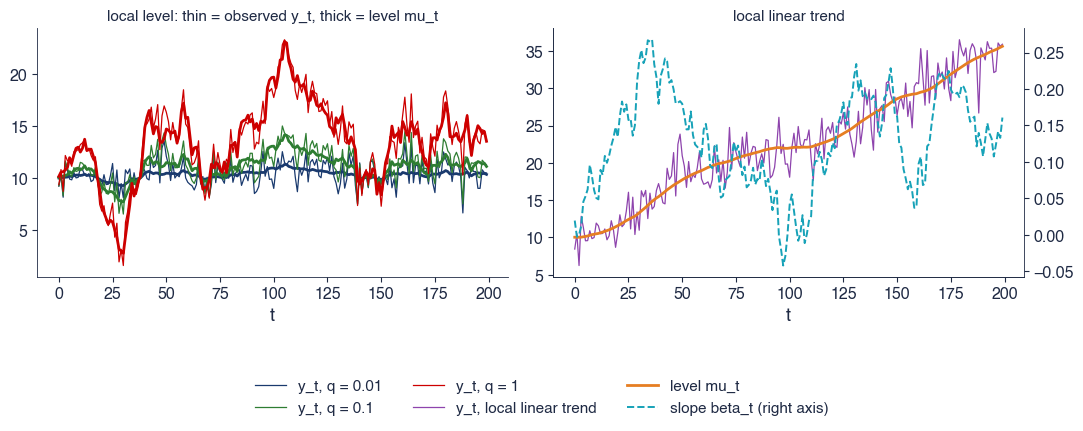

{'q0.01': {'sd_dy': 1.5221668547555618, 'acf1_dy': -0.506629375010711}, 'q0.1': {'sd_dy': 1.5503720078246743, 'acf1_dy': -0.47461435592679835}, 'q1': {'sd_dy': 1.8117301645338704, 'acf1_dy': -0.28213616931194146}, 'slope_last': 0.16079304998796976}
{'c': 0.4416345956778849, 'phi1': 0.31921308044939367, 'phi2': 0.11050922872771905, 's2': 0.7386451236451752, 'mu': 0.7744202566308079, 'n': 291, 'll_sarimax': -368.9157495361801, 'll_kalman': -368.91574953618044, 'P1': [[0.858319187348289, 0.3080264806012224], [0.3080264806012224, 0.858319187348289]]}


In [7]:
def fig_ss_examples(save_it=True, n=200):
    """Simulated local level paths for three signal-to-noise ratios (the same shocks) and a local linear trend."""
    rng = np.random.default_rng(SEED)
    eps, eta, zeta = rng.standard_normal(n), rng.standard_normal(n), rng.standard_normal(n)
    fig, axes = plt.subplots(1, 2, figsize=(11, 3.9))
    out = {}
    for q, c in [(0.01, st.MainBlue), (0.1, st.Forest), (1.0, st.IDAred)]:
        mu = 10 + np.cumsum(np.sqrt(q) * eta)
        y = mu + eps
        axes[0].plot(y, color=c, lw=0.9, label=f'y_t, q = {q:g}')
        axes[0].plot(mu, color=c, lw=2.0, label='_')
        out[f'q{q:g}'] = {'sd_dy': float(np.std(np.diff(y))), 'acf1_dy': float(np.corrcoef(np.diff(y)[1:], np.diff(y)[:-1])[0, 1])}
    axes[0].set_xlabel('t')
    axes[0].set_title('local level: thin = observed y_t, thick = level mu_t', fontsize=11)
    slope = 0.05 + np.cumsum(0.02 * zeta)
    mu = 10 + np.cumsum(slope)
    y = mu + 2 * eps
    axes[1].plot(y, color=st.Purple, lw=0.9, label='y_t, local linear trend')
    axes[1].plot(mu, color=st.Orange, lw=2.0, label='level mu_t')
    ax2 = axes[1].twinx()
    ax2.plot(slope, color=st.Teal, lw=1.4, ls='--', label='slope beta_t (right axis)')
    ax2.spines['right'].set_visible(True)
    axes[1].set_xlabel('t')
    axes[1].set_title('local linear trend', fontsize=11)
    h1, l1 = axes[0].get_legend_handles_labels()
    h2, l2 = axes[1].get_legend_handles_labels()
    h3, l3 = ax2.get_legend_handles_labels()
    st.fig_legend_bottom(fig, h1 + h2 + h3, l1 + l2 + l3, ncol=3, y=0.04)
    fig.tight_layout(rect=(0, 0.1, 1, 1))
    save('tsa_ch10_ss_examples', save_it)
    out['slope_last'] = float(slope[-1])
    return out


def arma_ss_check():
    """AR(2) with a constant for US real GDP growth (1947-2019) in state space form: the Kalman-filter
    log-likelihood with the stationary initial covariance equals the exact Gaussian likelihood of SARIMAX."""
    x = us_gdp_growth().loc[MS_SAMPLE[0]:MS_SAMPLE[1]].values
    r = sm.tsa.SARIMAX(x, order=(2, 0, 0), trend='c').fit(disp=False)
    c, p1, p2, s2 = r.params
    mu = c / (1 - p1 - p2)
    T = np.array([[p1, p2], [1.0, 0.0]])
    Q = np.array([[s2, 0.0], [0.0, 0.0]])
    P1 = np.linalg.solve(np.eye(4) - np.kron(T, T), Q.ravel()).reshape(2, 2)   # vec(P) = (I - T kron T)^-1 vec(Q)
    kf = kalman_filter(x - mu, [1.0, 0.0], T, 0.0, Q, [0.0, 0.0], P1)
    return {'c': float(c), 'phi1': float(p1), 'phi2': float(p2), 's2': float(s2), 'mu': float(mu), 'n': int(len(x)),
            'll_sarimax': float(r.llf), 'll_kalman': float(kf['loglik']), 'P1': P1.tolist()}


print(fig_ss_examples(save_it=False))
print(arma_ss_check())

## 2. The Kalman filter

- The three-period example; the Nile; the gain and exponential smoothing.

   t     y     a      P      F      K    v      af     Pf
0  1  12.0  10.0  4.000  8.000  0.500  2.0  11.000  2.000
1  2  11.0  11.0  3.000  7.000  0.429  0.0  11.000  1.714
2  3  14.0  11.0  2.714  6.714  0.404  3.0  12.213  1.617


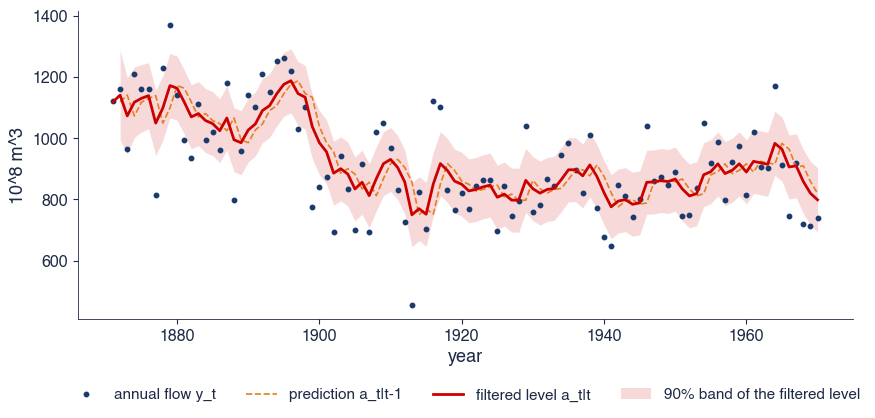

{'s2_eps': 15100.119, 's2_eta': 1468.393, 'q': 0.097, 'ss_K': 0.267, 'loglik': -632.544}
{'s2_eps': 15078.010819875257, 's2_eta': 1478.8114450783696, 'loglik': -632.5377605732459}


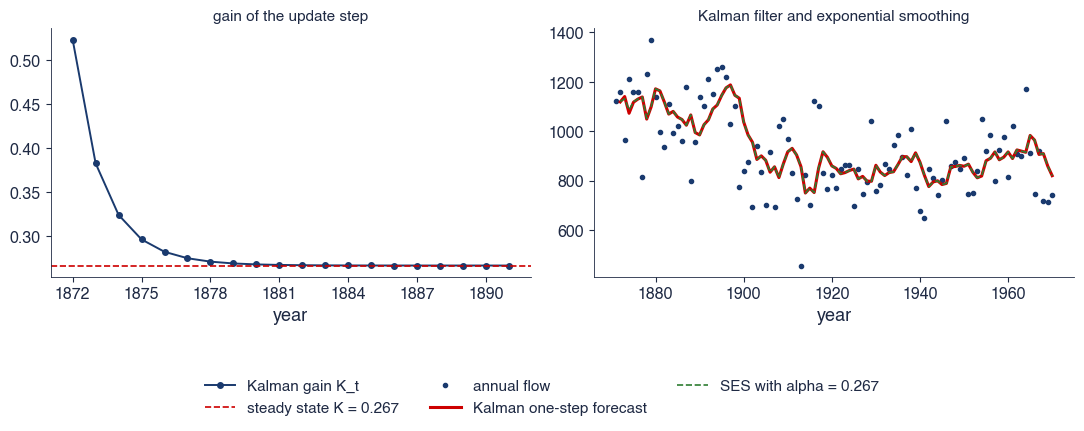

{'ss_K': 0.26698530217501254, 'alpha_ses': 0.24572797148588427, 'q_from_alpha': 0.08005365927398636, 'q': 0.09724382306246965, 'gap5': 0.2443199397503122, 'gap20': 0.01928547625561805, 'gap_max_after20': 0.01928547625561805, 'K_first': 0.5228406831454975, 'n_close': 10}


In [8]:
def fig_nile_filter(save_it=True):
    """Local level model of the Nile by maximum likelihood: data, one-step predictions a_t|t-1 and filtered level
    a_t|t with 90% bands."""
    y = nile()
    ml = local_level_ml(y.values)
    kf = ml['kf']
    yrs = y.index.values
    af, Pf = kf['a_filt'][:, 0], kf['P_filt'][:, 0, 0]
    ap = kf['a_pred'][:, 0]
    z = stats.norm.ppf(0.95)
    fig, ax = plt.subplots(figsize=(10, 4.0))
    ax.plot(yrs, y.values, 'o', ms=3.2, color=st.MainBlue, label='annual flow y_t')
    ax.plot(yrs[1:], ap[1:], color=st.Orange, lw=1.2, ls='--', label='prediction a_t|t-1')
    ax.plot(yrs, af, color=st.IDAred, lw=2.0, label='filtered level a_t|t')
    ax.fill_between(yrs[1:], (af - z * np.sqrt(Pf))[1:], (af + z * np.sqrt(Pf))[1:], color=st.IDAred, alpha=0.15,
                    lw=0, label='90% band of the filtered level')
    ax.set_xlabel('year')
    ax.set_ylabel('10^8 m^3')
    st.legend_outside_bottom(ax, ncol=4, y=-0.18)
    save('tsa_ch10_nile_filter', save_it)
    ss = steady_state(ml['q'])
    i98, i99 = list(yrs).index(1898), list(yrs).index(1899)
    return {'s2_eps': ml['s2_eps'], 's2_eta': ml['s2_eta'], 'q': ml['q'], 'loglik': ml['loglik'], 'aic': ml['aic'],
            'bic': ml['bic'], 'n': int(len(y)), 'ss_K': ss['K'], 'ss_P': ss['P'] * ml['s2_eps'],
            'K2': float(kf['K'][1, 0]), 'K5': float(kf['K'][4, 0]), 'K10': float(kf['K'][9, 0]),
            'a_last': float(af[-1]), 'sd_last': float(np.sqrt(Pf[-1])), 'y_mean': float(y.mean()),
            'a1898': float(af[i98]), 'a1899': float(af[i99]), 'y1899': float(y.values[i99]),
            'v1899': float(kf['v'][i99]), 'K1899': float(kf['K'][i99, 0]), 'a_pred1899': float(ap[i99]),
            'af_1900': float(af[i99 + 1]), 'af_1905': float(af[i99 + 6]), 'sm': {k: ml[k] for k in ('s2_eps', 's2_eta')}}


def statsmodels_local_level():
    """The same model with statsmodels UnobservedComponents('llevel') (exact diffuse initialisation)."""
    r = sm.tsa.UnobservedComponents(nile().values, 'llevel').fit(disp=False)
    return {'s2_eps': float(r.params[0]), 's2_eta': float(r.params[1]), 'loglik': float(r.llf)}


def fig_gain_ses(save_it=True):
    """The Kalman gain K_t and the prediction variance P_t converge to their steady state; with alpha = steady-state
    gain, simple exponential smoothing gives the same one-step forecasts as the Kalman filter."""
    y = nile()
    ml = local_level_ml(y.values)
    kf, yrs = ml['kf'], y.index.values
    ss = steady_state(ml['q'])
    K = kf['K'][:, 0]
    fig, axes = plt.subplots(1, 2, figsize=(11, 3.9))
    axes[0].plot(yrs[1:21], K[1:21], 'o-', color=st.MainBlue, ms=4, label='Kalman gain K_t')
    axes[0].axhline(ss['K'], color=st.IDAred, ls='--', lw=1.2, label=f'steady state K = {ss["K"]:.3f}')
    axes[0].set_xlabel('year')
    axes[0].xaxis.set_major_locator(plt.MaxNLocator(integer=True))
    axes[0].set_title('gain of the update step', fontsize=11)
    ses_fit = sm.tsa.SimpleExpSmoothing(y.values, initialization_method='estimated').fit()
    alpha_ses = float(ses_fit.params['smoothing_level'])
    f_k = kf['a_pred'][1:, 0]
    f_s = ses_path(y.values, ss['K'], y.values[0])[1:]
    axes[1].plot(yrs, y.values, 'o', ms=3, color=st.MainBlue, label='annual flow')
    axes[1].plot(yrs[1:], f_k, color=st.IDAred, lw=2.2, label='Kalman one-step forecast')
    axes[1].plot(yrs[1:], f_s, color=st.Forest, lw=1.2, ls='--', label=f'SES with alpha = {ss["K"]:.3f}')
    axes[1].set_xlabel('year')
    axes[1].set_title('Kalman filter and exponential smoothing', fontsize=11)
    st.fig_legend_bottom(fig, ncol=3, y=0.04)
    fig.tight_layout(rect=(0, 0.1, 1, 1))
    save('tsa_ch10_gain_ses', save_it)
    gap = np.abs(f_k - f_s)
    return {'ss_K': ss['K'], 'alpha_ses': alpha_ses, 'q_from_alpha': float(q_from_alpha(alpha_ses)),
            'q': ml['q'], 'gap5': float(gap[4]), 'gap20': float(gap[19]), 'gap_max_after20': float(gap[19:].max()),
            'K_first': float(K[1]), 'n_close': int(np.argmax(np.abs(K[1:] - ss['K']) < 0.001) + 1)}


print(pd.DataFrame(worked_example()['rows']).round(3))
nf = fig_nile_filter(save_it=False)
print({k: round(nf[k], 3) for k in ('s2_eps', 's2_eta', 'q', 'ss_K', 'loglik')})
print(statsmodels_local_level())
print(fig_gain_ses(save_it=False))

## 3. Smoothing, likelihood and diagnostics

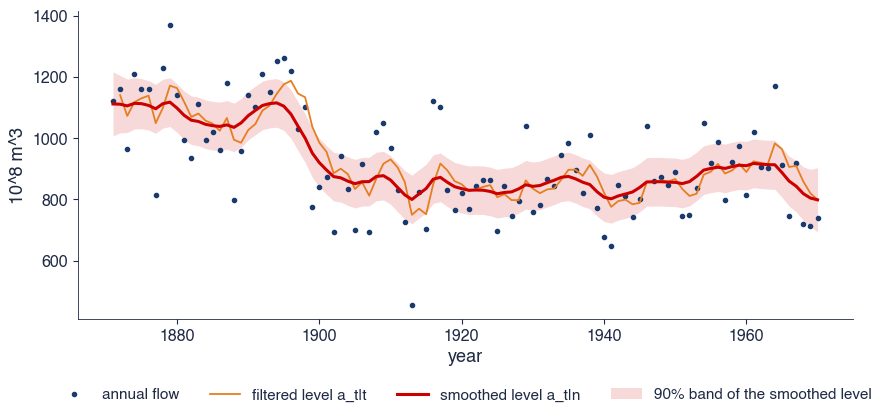

{'sd_f_mid': 63.49417124945657, 'sd_s_mid': 48.231718481724094, 'sd_s_end': 63.49417124945413, 'sd_f_end': 63.49417124945413, 's1871': 1111.2179494557465, 's1897': 1038.4566399813468, 's1900': 919.50427317007, 's1970': 798.3901475595492, 'f1897': 1145.1919178942808, 'f1900': 984.58339630984}


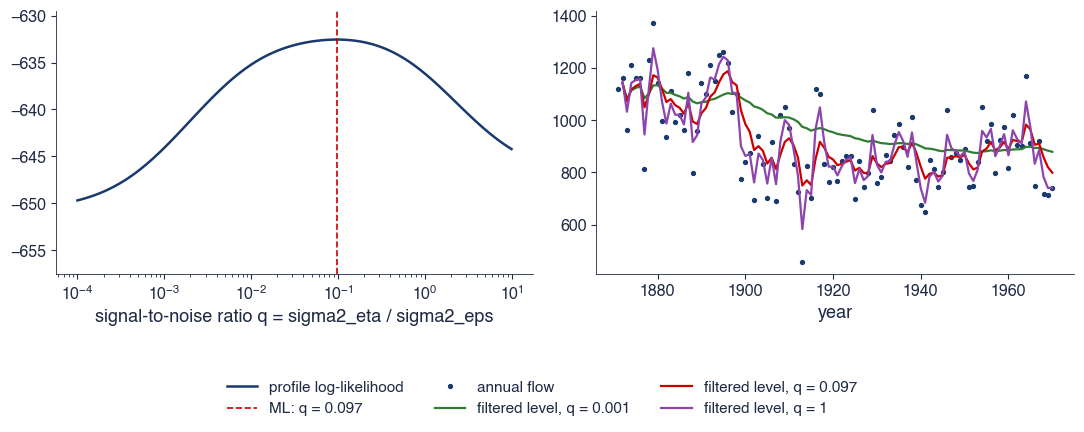

{'q': 0.09724382306246965, 'll': -632.5456252039588, 's2_conc': 15099.970475361097, 'll_q001': -644.0863350118617, 'll_q1': -636.1600192964112, 'lr_q001': 23.08141961580577, 'lr_q1': 7.228788184904715}


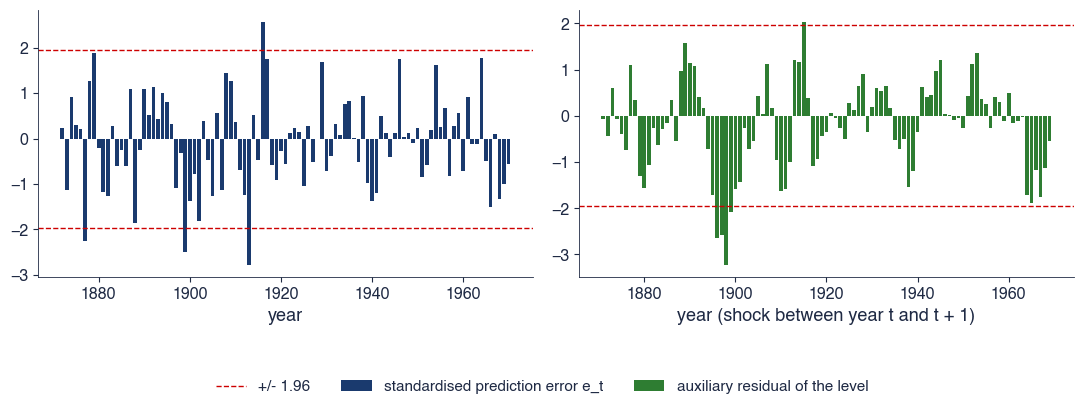

{'lb10': 13.200121479450216, 'lb10_p': 0.2126970767567937, 'jb': 0.04672980225401271, 'jb_p': 0.976905944646288, 'acf1': 0.11510089152507294, 'n_out': 4, 'n_e': 99, 'lev_min_year': 1898, 'lev_min': -3.2340081203813424, 'obs_min_year': 1913, 'obs_min': -3.0390263504111066, 'e_min_year': 1913, 'e_min': -2.7892792454789315}


In [9]:
def fig_nile_smooth(save_it=True):
    """Filtered (one-sided) against smoothed (two-sided, RTS) level of the Nile with 90% bands."""
    y = nile()
    ml = local_level_ml(y.values)
    kf = ml['kf']
    a_s, P_s = rts_smoother(kf)
    yrs = y.index.values
    af, Pf = kf['a_filt'][:, 0], kf['P_filt'][:, 0, 0]
    a_s, P_s = a_s[:, 0], P_s[:, 0, 0]
    z = stats.norm.ppf(0.95)
    fig, ax = plt.subplots(figsize=(10, 4.0))
    ax.plot(yrs, y.values, 'o', ms=3, color=st.MainBlue, label='annual flow')
    ax.plot(yrs[1:], af[1:], color=st.Orange, lw=1.3, label='filtered level a_t|t')
    ax.plot(yrs, a_s, color=st.IDAred, lw=2.2, label='smoothed level a_t|n')
    ax.fill_between(yrs, a_s - z * np.sqrt(P_s), a_s + z * np.sqrt(P_s), color=st.IDAred, alpha=0.15, lw=0,
                    label='90% band of the smoothed level')
    ax.set_xlabel('year')
    ax.set_ylabel('10^8 m^3')
    st.legend_outside_bottom(ax, ncol=4, y=-0.18)
    save('tsa_ch10_nile_smooth', save_it)
    i = list(yrs).index
    return {'sd_f_mid': float(np.sqrt(Pf[i(1920)])), 'sd_s_mid': float(np.sqrt(P_s[i(1920)])),
            'sd_s_end': float(np.sqrt(P_s[-1])), 'sd_f_end': float(np.sqrt(Pf[-1])),
            's1871': float(a_s[0]), 's1897': float(a_s[i(1897)]), 's1900': float(a_s[i(1900)]), 's1970': float(a_s[-1]),
            'f1897': float(af[i(1897)]), 'f1900': float(af[i(1900)])}


def fig_likelihood(save_it=True):
    """Profile log-likelihood of the local level model over q (sigma2_eps concentrated out) and the filtered level
    for a small, the ML and a large q."""
    y = nile()
    ml = local_level_ml(y.values)
    qs = np.logspace(-4, 1, 120)
    ll = np.array([profile_loglik(y.values, q)[0] for q in qs])
    fig, axes = plt.subplots(1, 2, figsize=(11, 3.9))
    axes[0].semilogx(qs, ll, color=st.MainBlue, lw=1.8, label='profile log-likelihood')
    axes[0].axvline(ml['q'], color=st.IDAred, ls='--', lw=1.2, label=f'ML: q = {ml["q"]:.3f}')
    axes[0].set_xlabel('signal-to-noise ratio q = sigma2_eta / sigma2_eps')
    axes[0].set_ylim(ll.max() - 25, ll.max() + 3)
    yrs = y.index.values
    axes[1].plot(yrs, y.values, 'o', ms=2.8, color=st.MainBlue, label='annual flow')
    for q, c in [(0.001, st.Forest), (ml['q'], st.IDAred), (1.0, st.Purple)]:
        kf = local_level_filter(y.values, 1.0, q)
        lab = f'filtered level, q = {q:.3f}' if q == ml['q'] else f'filtered level, q = {q:g}'
        axes[1].plot(yrs[1:], kf['a_filt'][1:, 0], color=c, lw=1.6, label=lab)
    axes[1].set_xlabel('year')
    st.fig_legend_bottom(fig, ncol=3, y=0.04)
    fig.tight_layout(rect=(0, 0.1, 1, 1))
    save('tsa_ch10_likelihood', save_it)
    ll_ml, s2 = profile_loglik(y.values, ml['q'])
    return {'q': ml['q'], 'll': ll_ml, 's2_conc': s2, 'll_q001': profile_loglik(y.values, 0.001)[0],
            'll_q1': profile_loglik(y.values, 1.0)[0], 'lr_q001': float(2 * (ll_ml - profile_loglik(y.values, 0.001)[0])),
            'lr_q1': float(2 * (ll_ml - profile_loglik(y.values, 1.0)[0]))}


def fig_diagnostics(save_it=True):
    """Standardised one-step prediction errors e_t = v_t / sqrt(F_t) with their ACF and Ljung-Box test, and the
    standardised auxiliary residual of the level (smoothed level disturbance), which points at the 1899 break."""
    y = nile()
    ml = local_level_ml(y.values)
    kf = ml['kf']
    yrs = y.index.values
    e = (kf['v'] / np.sqrt(kf['F']))[1:]
    obs_std, state_std = disturbance_smoother(kf)
    lev = state_std[:, 0]
    lb = sm.stats.acorr_ljungbox(e, lags=[10], return_df=True)
    jb = stats.jarque_bera(e)
    fig, axes = plt.subplots(1, 2, figsize=(11, 3.9))
    axes[0].bar(yrs[1:], e, color=st.MainBlue, width=0.8, label='standardised prediction error e_t')
    axes[0].axhline(1.96, color=st.IDAred, ls='--', lw=1, label='+/- 1.96')
    axes[0].axhline(-1.96, color=st.IDAred, ls='--', lw=1, label='_')
    axes[0].set_xlabel('year')
    axes[1].bar(yrs[:-1], lev[:-1], color=st.Forest, width=0.8, label='auxiliary residual of the level')
    axes[1].axhline(1.96, color=st.IDAred, ls='--', lw=1, label='_')
    axes[1].axhline(-1.96, color=st.IDAred, ls='--', lw=1, label='_')
    axes[1].set_xlabel('year (shock between year t and t + 1)')
    st.fig_legend_bottom(fig, ncol=3, y=0.04)
    fig.tight_layout(rect=(0, 0.1, 1, 1))
    save('tsa_ch10_diagnostics', save_it)
    k = int(np.nanargmin(lev[:-1]))
    acf = sm.tsa.acf(e, nlags=10)
    return {'lb10': float(lb['lb_stat'].iloc[0]), 'lb10_p': float(lb['lb_pvalue'].iloc[0]), 'jb': float(jb.statistic),
            'jb_p': float(jb.pvalue), 'acf1': float(acf[1]), 'n_out': int((np.abs(e) > 1.96).sum()), 'n_e': int(len(e)),
            'lev_min_year': int(yrs[k]), 'lev_min': float(lev[k]), 'obs_min_year': int(yrs[int(np.nanargmin(obs_std))]),
            'obs_min': float(np.nanmin(obs_std)), 'e_min_year': int(yrs[1:][int(np.argmin(e))]), 'e_min': float(e.min())}


print(fig_nile_smooth(save_it=False))
print(fig_likelihood(save_it=False))
print(fig_diagnostics(save_it=False))

## 4. Missing values and forecasts

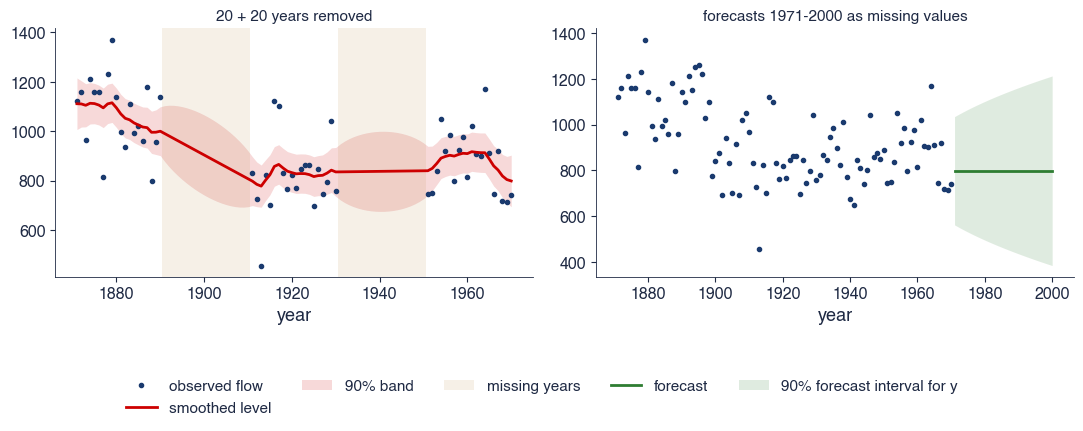

{'sd_gap_mid': 98.54430062301485, 'sd_full_mid': 48.231718746900185, 'sd_obs': 48.32446485248554, 'f1': 798.3901475595492, 'sd_f1': 143.5270771370793, 'sd_f30': 251.36313778212158, 'n_missing': 40, 'P_growth': 1468.393281522785}


In [10]:
def fig_missing(save_it=True, H=30):
    """Missing observations (1891-1910 and 1931-1950 removed) and forecasting 30 years ahead as missing data."""
    y = nile()
    ml = local_level_ml(y.values)
    yrs = y.index.values
    ym = y.values.copy()
    for a, b in NILE_GAPS:
        ym[(yrs >= a) & (yrs <= b)] = np.nan
    kf = local_level_filter(ym, ml['s2_eps'], ml['s2_eta'])
    a_s, P_s = rts_smoother(kf)
    z = stats.norm.ppf(0.95)
    ext = np.r_[y.values, np.full(H, np.nan)]
    yrs_ext = np.r_[yrs, np.arange(yrs[-1] + 1, yrs[-1] + H + 1)]
    kf2 = local_level_filter(ext, ml['s2_eps'], ml['s2_eta'])
    fig, axes = plt.subplots(1, 2, figsize=(11, 3.9))
    axes[0].plot(yrs, ym, 'o', ms=3, color=st.MainBlue, label='observed flow')
    axes[0].plot(yrs, a_s[:, 0], color=st.IDAred, lw=2, label='smoothed level')
    axes[0].fill_between(yrs, a_s[:, 0] - z * np.sqrt(P_s[:, 0, 0]), a_s[:, 0] + z * np.sqrt(P_s[:, 0, 0]),
                         color=st.IDAred, alpha=0.15, lw=0, label='90% band')
    for a, b in NILE_GAPS:
        axes[0].axvspan(a - 0.5, b + 0.5, color=SHADE, alpha=0.12, lw=0, label='missing years' if a == NILE_GAPS[0][0] else '_')
    axes[0].set_xlabel('year')
    axes[0].set_title('20 + 20 years removed', fontsize=11)
    ap, Pp = kf2['a_pred'][:, 0], kf2['P_pred'][:, 0, 0]
    F = Pp + ml['s2_eps']
    fut = yrs_ext > yrs[-1]
    axes[1].plot(yrs, y.values, 'o', ms=3, color=st.MainBlue, label='_')
    axes[1].plot(yrs_ext[fut], ap[fut], color=st.Forest, lw=2, label='forecast')
    axes[1].fill_between(yrs_ext[fut], ap[fut] - z * np.sqrt(F[fut]), ap[fut] + z * np.sqrt(F[fut]), color=st.Forest,
                         alpha=0.15, lw=0, label='90% forecast interval for y')
    axes[1].set_xlabel('year')
    axes[1].set_title('forecasts 1971-2000 as missing values', fontsize=11)
    st.fig_legend_bottom(fig, ncol=5, y=0.04)
    fig.tight_layout(rect=(0, 0.1, 1, 1))
    save('tsa_ch10_missing', save_it)
    i = list(yrs).index
    full = local_level_filter(y.values, ml['s2_eps'], ml['s2_eta'])
    fs, Fs = rts_smoother(full)
    return {'sd_gap_mid': float(np.sqrt(P_s[i(1900), 0, 0])), 'sd_full_mid': float(np.sqrt(Fs[i(1900), 0, 0])),
            'sd_obs': float(np.sqrt(P_s[i(1880), 0, 0])), 'f1': float(ap[fut][0]), 'sd_f1': float(np.sqrt(F[fut][0])),
            'sd_f30': float(np.sqrt(F[fut][-1])), 'n_missing': int(np.isnan(ym).sum()),
            'P_growth': float(ml['s2_eta'])}


print(fig_missing(save_it=False))

## 5. Trend and cycle of Romanian GDP

- UC model, HP filter, Hamilton filter; real time against hindsight.

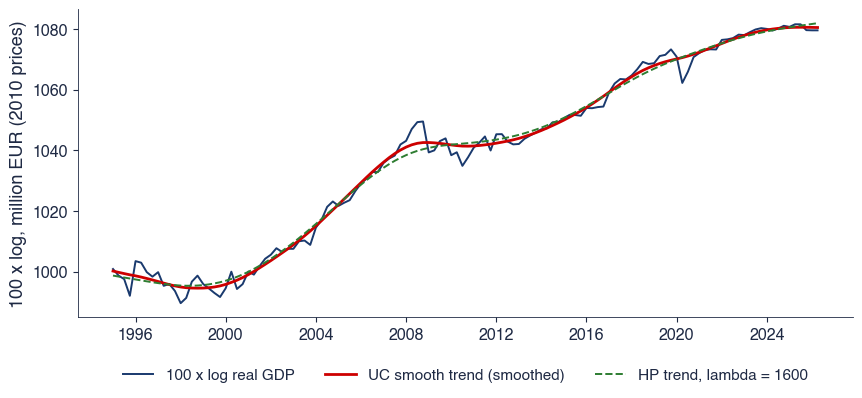

{'s2_irr': 6.114933140906075e-10, 's2_trend': 0.07787824598388117, 's2_ar': 5.272959714410764, 'phi1': 0.6149413734381728, 'phi2': -0.1332005233965646, 'loglik': -302.5954092892191, 'n': 126, 'first': '1995-01-01', 'last': '2026-04-01', 'lam_ratio': 67.70773593825075, 'g_max': 7.2396220425707725, 'g_max_d': '2005-10-01', 'g_min': -2.117328316756357, 'g_min_d': '1997-04-01', 'g_last': -0.15365008336902974, 'avg_growth': 2.516689268353137}


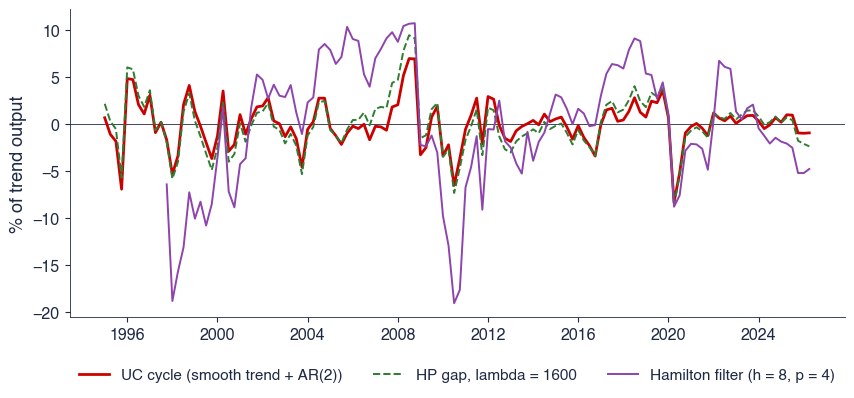

{'sd_uc': 2.404118779212175, 'sd_hp': 2.851121836396744, 'sd_ham': 6.543081721692081, 'c_uc_hp': 0.9412490205706268, 'c_uc_ham': 0.5678923256958933, 'c_hp_ham': 0.6892866434869879, 'last_uc': -0.9290561468479335, 'last_hp': -2.3585348108197195, 'last_ham': -4.766072820164709, 'last_d': '2026-04-01', 'peak_uc': 6.977963325982209, 'peak_uc_d': '2008-07-01', 'peak_hp': 9.464614457766402, 'peak_ham': 10.746304746772239, 'ham_b': [0.7616047698334404, 0.06127254988790862, 0.35370767598012276, -0.20535242324627093], 'ham_bsum': 0.9712325724552009, 'uc2020': -8.339652960741349, 'hp2020': -8.507195718071443}


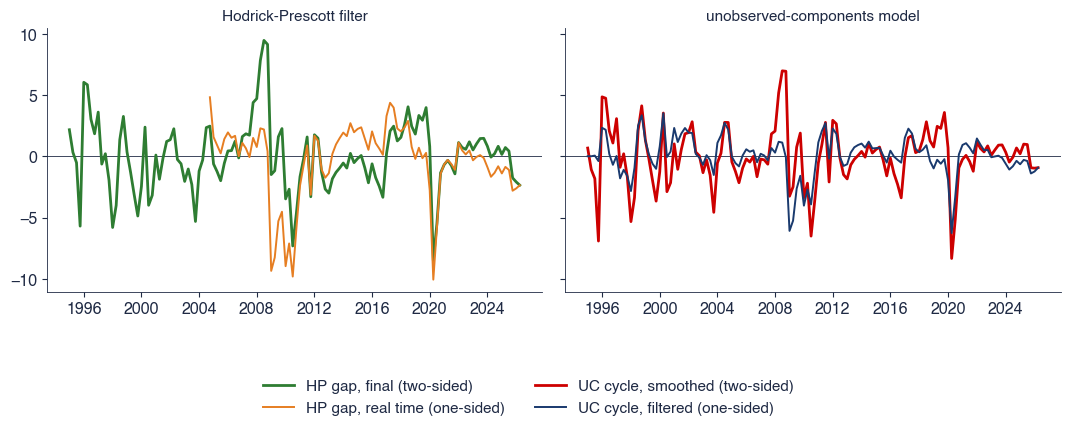

{'rev_hp': 2.803745032973766, 'rev_uc': 1.7589354095492653, 'c_hp': 0.5691524005366223, 'c_uc': 0.6471400291423447, 'hp_rt_2008': 2.1894560839780297, 'hp_fin_2008': 9.464614457766402, 'uc_f_2008': 1.1213984987422283, 'uc_s_2008': 6.977963325982209, 'start': '2004-10-01'}


In [11]:
def fig_ro_trend(save_it=True):
    """Log Romanian real GDP with the smooth trend of the UC model and the HP trend."""
    y = ro_gdp()
    r = uc_fit(y.values)
    hc, ht = hp(y.values)
    fig, ax = plt.subplots(figsize=(10, 4.0))
    ax.plot(y.index, y.values, color=st.MainBlue, lw=1.4, label='100 x log real GDP')
    ax.plot(y.index, r.level.smoothed, color=st.IDAred, lw=2, label='UC smooth trend (smoothed)')
    ax.plot(y.index, ht, color=st.Forest, lw=1.4, ls='--', label='HP trend, lambda = 1600')
    ax.set_ylabel('100 x log, million EUR (2010 prices)')
    st.legend_outside_bottom(ax, ncol=3, y=-0.12)
    save('tsa_ch10_ro_trend', save_it)
    p = dict(zip(r.model.param_names, r.params))
    tr = r.level.smoothed
    g = 4 * np.diff(tr)
    return {'s2_irr': float(p['sigma2.irregular']), 's2_trend': float(p['sigma2.trend']), 's2_ar': float(p['sigma2.ar']),
            'phi1': float(p['ar.L1']), 'phi2': float(p['ar.L2']), 'loglik': float(r.llf), 'n': int(len(y)),
            'first': str(y.index[0].date()), 'last': str(y.index[-1].date()), 'lam_ratio': float(p['sigma2.ar'] / p['sigma2.trend']),
            'g_max': float(g.max()), 'g_max_d': str(y.index[1:][int(np.argmax(g))].date()), 'g_min': float(g.min()),
            'g_min_d': str(y.index[1:][int(np.argmin(g))].date()), 'g_last': float(g[-1]),
            'avg_growth': float(4 * (y.values[-1] - y.values[0]) / (len(y) - 1))}


def fig_output_gap(save_it=True):
    """Romanian output gap: UC cycle (smoothed), HP gap and Hamilton (2018) regression filter."""
    y = ro_gdp()
    r = uc_fit(y.values)
    uc = r.autoregressive.smoothed
    hc, _ = hp(y.values)
    hm, hr = hamilton_filter(y.values)
    fig, ax = plt.subplots(figsize=(10, 4.0))
    ax.axhline(0, color=st.DarkText, lw=0.6)
    ax.plot(y.index, uc, color=st.IDAred, lw=2, label='UC cycle (smooth trend + AR(2))')
    ax.plot(y.index, hc, color=st.Forest, lw=1.4, ls='--', label='HP gap, lambda = 1600')
    ax.plot(y.index, hm, color=st.Purple, lw=1.4, label='Hamilton filter (h = 8, p = 4)')
    ax.set_ylabel('% of trend output')
    st.legend_outside_bottom(ax, ncol=3, y=-0.12)
    save('tsa_ch10_output_gap', save_it)
    ok = ~np.isnan(hm)
    yr = pd.Series(uc, index=y.index)
    def peak(x):
        s = pd.Series(x, index=y.index)
        return float(s.loc['2007':'2009'].max()), str(s.loc['2007':'2009'].idxmax().date())
    return {'sd_uc': float(np.std(uc)), 'sd_hp': float(np.std(hc)), 'sd_ham': float(np.nanstd(hm)),
            'c_uc_hp': float(np.corrcoef(uc, hc)[0, 1]), 'c_uc_ham': float(np.corrcoef(uc[ok], hm[ok])[0, 1]),
            'c_hp_ham': float(np.corrcoef(hc[ok], hm[ok])[0, 1]), 'last_uc': float(uc[-1]), 'last_hp': float(hc[-1]),
            'last_ham': float(hm[-1]), 'last_d': str(y.index[-1].date()),
            'peak_uc': peak(uc)[0], 'peak_uc_d': peak(uc)[1], 'peak_hp': peak(hc)[0], 'peak_ham': peak(hm)[0],
            'ham_b': [float(b) for b in hr.params.values[1:]], 'ham_bsum': float(hr.params.values[1:].sum()),
            'uc2020': float(yr.loc['2020-04-01']), 'hp2020': float(pd.Series(hc, index=y.index).loc['2020-04-01'])}


def fig_realtime(save_it=True):
    """Real-time against final estimates of the gap: one-sided against two-sided HP, filtered against smoothed UC."""
    y = ro_gdp()
    r = uc_fit(y.values)
    hc, _ = hp(y.values)
    rt = hp_realtime(y.values)
    ucf, ucs = r.autoregressive.filtered, r.autoregressive.smoothed
    fig, axes = plt.subplots(1, 2, figsize=(11, 3.9), sharey=True)
    for ax in axes:
        ax.axhline(0, color=st.DarkText, lw=0.6)
    axes[0].plot(y.index, hc, color=st.Forest, lw=2, label='HP gap, final (two-sided)')
    axes[0].plot(y.index, rt, color=st.Orange, lw=1.4, label='HP gap, real time (one-sided)')
    axes[0].set_title('Hodrick-Prescott filter', fontsize=11)
    axes[1].plot(y.index, ucs, color=st.IDAred, lw=2, label='UC cycle, smoothed (two-sided)')
    axes[1].plot(y.index, ucf, color=st.MainBlue, lw=1.4, label='UC cycle, filtered (one-sided)')
    axes[1].set_title('unobserved-components model', fontsize=11)
    st.fig_legend_bottom(fig, ncol=2, y=0.04)
    fig.tight_layout(rect=(0, 0.12, 1, 1))
    save('tsa_ch10_realtime', save_it)
    ok = ~np.isnan(rt)
    s = lambda x: pd.Series(x, index=y.index)
    return {'rev_hp': float(np.sqrt(np.nanmean((rt - hc) ** 2))), 'rev_uc': float(np.sqrt(np.mean((ucf - ucs)[ok] ** 2))),
            'c_hp': float(np.corrcoef(rt[ok], hc[ok])[0, 1]), 'c_uc': float(np.corrcoef(ucf[ok], ucs[ok])[0, 1]),
            'hp_rt_2008': float(s(rt).loc['2008-07-01']), 'hp_fin_2008': float(s(hc).loc['2008-07-01']),
            'uc_f_2008': float(s(ucf).loc['2008-07-01']), 'uc_s_2008': float(s(ucs).loc['2008-07-01']),
            'start': str(y.index[ok][0].date())}


print(fig_ro_trend(save_it=False))
print(fig_output_gap(save_it=False))
print(fig_realtime(save_it=False))

## 6. A time-varying beta and a dynamic factor

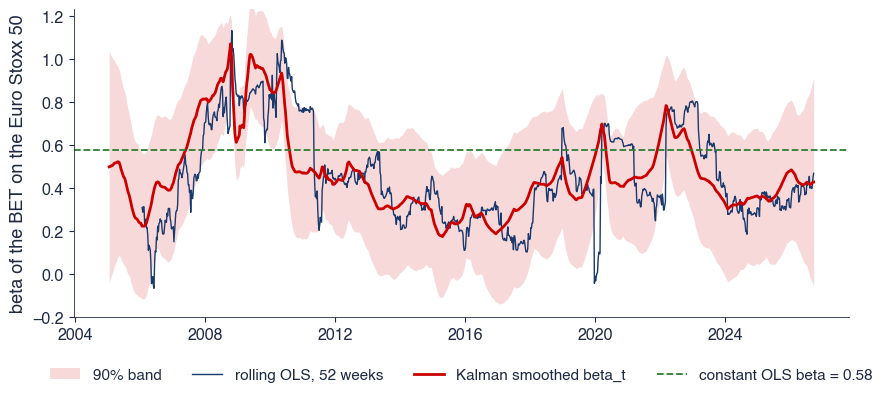

{'s2_eps': 6.753080018501633, 's2_beta': 0.0034354166679563267, 'sd_beta': 0.05861242758968721, 'loglik': -2706.300374111463, 'loglik_const': -2729.350900650941, 'lr': 46.101053078956284, 'beta_ols': 0.5800502793028385, 'n': 1126, 'b_min': 0.17490657507904772, 'b_min_d': '2015-04-17', 'b_max': 1.072570679869823, 'b_max_d': '2008-10-10', 'b_last': 0.42905842768716607, 'sd_last': 0.2944141352791955, 'first': '2005-01-14', 'last': '2026-09-18', 'roll_sd': 0.03887116361809941, 'kf_sd': 0.009687769924780673}


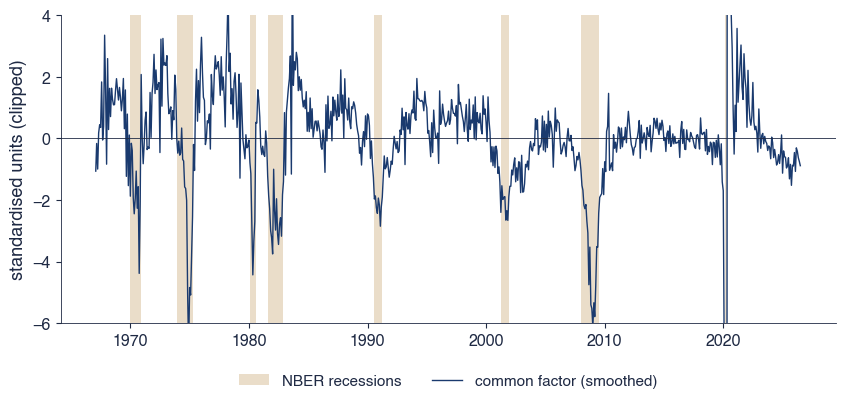

{'loadings': {'INDPRO': 0.41995156173822235, 'PAYEMS': 0.5910138699633491, 'W875RX1': 0.2343567261153512, 'CMRMTSPL': 0.2935405275458014}, 'phi1': 0.4196099369202199, 'phi2': 0.40874365574184346, 'n_est': 635, 'mean_rec': -3.46420422775064, 'mean_exp': 0.39590406012397306, 'covid_min': -73.96621711212282, 'covid_min_d': '2020-04-01', 'last': -0.886371881626734, 'last_d': '2026-07-01', 'last_filt': -0.886371881626734, 'corr_avg': 0.8569545387231026, 'share_neg_rec': 0.9882352941176471}


In [12]:
def fig_tvp_beta(save_it=True):
    """Time-varying beta of the BET on the Euro Stoxx 50 (weekly returns): Kalman smoothed beta with a 90% band,
    52-week rolling OLS and the constant OLS beta."""
    r = tvp_data()
    y, x = r.iloc[:, 0].values, r.iloc[:, 1].values
    f = lambda th: -tvp_filter(y, x, np.exp(th[0]), np.exp(th[1]))['loglik']
    o = optimize.minimize(f, [np.log(np.var(y) / 2), np.log(1e-3)], method='Nelder-Mead', options={'maxiter': 4000, 'xatol': 1e-7, 'fatol': 1e-7})
    s2e, s2b = np.exp(o.x)
    kf = tvp_filter(y, x, s2e, s2b)
    a_s, P_s = rts_smoother(kf)
    b_s, sd_s = a_s[:, 1], np.sqrt(P_s[:, 1, 1])
    ols = sm.OLS(y, sm.add_constant(x)).fit()
    roll = pd.Series(np.nan, index=r.index)
    for t in range(ROLL, len(r) + 1):
        roll.iloc[t - 1] = np.polyfit(x[t - ROLL:t], y[t - ROLL:t], 1)[0]
    z = stats.norm.ppf(0.95)
    const_ll = tvp_filter(y, x, float(np.var(ols.resid)), 0.0)['loglik']
    o0 = optimize.minimize_scalar(lambda s: -tvp_filter(y, x, np.exp(s), 0.0)['loglik'], bounds=(-5, 5), method='bounded')
    ll0 = -o0.fun
    fig, ax = plt.subplots(figsize=(10, 4.0))
    ax.fill_between(r.index, b_s - z * sd_s, b_s + z * sd_s, color=st.IDAred, alpha=0.15, lw=0, label='90% band')
    ax.plot(r.index, roll.values, color=st.MainBlue, lw=1.0, label=f'rolling OLS, {ROLL} weeks')
    ax.plot(r.index, b_s, color=st.IDAred, lw=2, label='Kalman smoothed beta_t')
    ax.axhline(ols.params[1], color=st.Forest, ls='--', lw=1.3, label=f'constant OLS beta = {ols.params[1]:.2f}')
    ax.set_ylabel('beta of the BET on the Euro Stoxx 50')
    ax.set_ylim(min(-0.2, np.nanmin(roll.values) - 0.1), np.nanmax(roll.values) + 0.1)
    st.legend_outside_bottom(ax, ncol=4, y=-0.12)
    save('tsa_ch10_tvp_beta', save_it)
    bs = pd.Series(b_s, index=r.index)
    return {'s2_eps': float(s2e), 's2_beta': float(s2b), 'sd_beta': float(np.sqrt(s2b)), 'loglik': float(-o.fun),
            'loglik_const': float(ll0), 'lr': float(2 * (-o.fun - ll0)), 'beta_ols': float(ols.params[1]), 'n': int(len(r)),
            'b_min': float(bs.min()), 'b_min_d': str(bs.idxmin().date()), 'b_max': float(bs.max()), 'b_max_d': str(bs.idxmax().date()),
            'b_last': float(b_s[-1]), 'sd_last': float(sd_s[-1]), 'first': str(r.index[0].date()), 'last': str(r.index[-1].date()),
            'roll_sd': float(np.nanstd(np.diff(roll.dropna().values))), 'kf_sd': float(np.std(np.diff(b_s)))}


def fig_dfm(save_it=True):
    """One-factor dynamic factor model (AR(2) factor) of the four coincident indicators, estimated on 1967-2019 and
    run by the Kalman filter through the last month; the last two months of income and sales set to missing (the
    ragged edge of a nowcast)."""
    z = coincident()
    mod = sm.tsa.DynamicFactor(z.loc[:'2019'], k_factors=1, factor_order=2)
    r = mod.fit(disp=False, maxiter=2000)
    zz = z.copy()
    zz.iloc[-2:, [2, 3]] = np.nan                                  # ragged edge
    full = sm.tsa.DynamicFactor(zz, k_factors=1, factor_order=2).smooth(r.params)
    f = pd.Series(full.factors.smoothed[0], index=z.index)
    ff = pd.Series(full.factors.filtered[0], index=z.index)
    p = pd.Series(r.params, index=mod.param_names)
    sign = 1.0 if p['loading.f1.PAYEMS'] > 0 else -1.0
    f, ff = sign * f, sign * ff
    rec = nber('MS').reindex(z.index)
    fig, ax = plt.subplots(figsize=(10, 4.0))
    shade(ax, rec)
    ax.plot(f.index, f.values, color=st.MainBlue, lw=1.0, label='common factor (smoothed)')
    ax.axhline(0, color=st.DarkText, lw=0.6)
    ax.set_ylim(-6, 4)
    ax.set_ylabel('standardised units (clipped)')
    st.legend_outside_bottom(ax, ncol=2, y=-0.12)
    save('tsa_ch10_dfm', save_it)
    load = {k: float(sign * p[f'loading.f1.{k}']) for k in COINCIDENT}
    return {'loadings': load, 'phi1': float(p['L1.f1.f1']), 'phi2': float(p['L2.f1.f1']), 'n_est': int(len(z.loc[:'2019'])),
            'mean_rec': float(f[rec == 1].mean()), 'mean_exp': float(f[rec == 0].mean()),
            'covid_min': float(f.loc['2020'].min()), 'covid_min_d': str(f.loc['2020'].idxmin().date()),
            'last': float(f.iloc[-1]), 'last_d': str(f.index[-1].date()), 'last_filt': float(ff.iloc[-1]),
            'corr_avg': float(np.corrcoef(f.loc[:'2019'], z.loc[:'2019'].mean(1))[0, 1]),
            'share_neg_rec': float((f[rec == 1] < 0).mean())}


print(fig_tvp_beta(save_it=False))
print(fig_dfm(save_it=False))

## 7. Markov switching: US and Romanian GDP

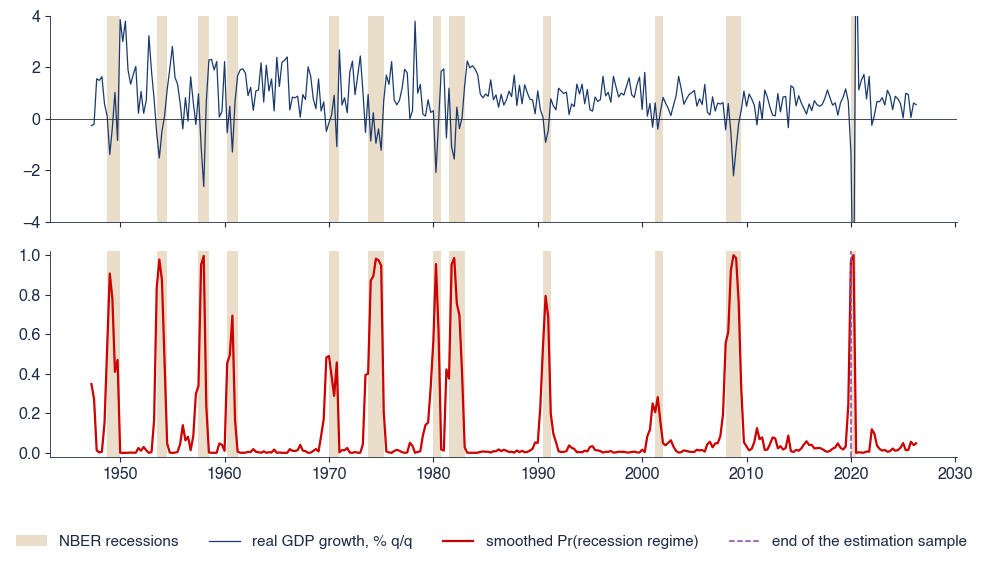

{'p11': 0.7620319971611365, 'p22': 0.8919806527596692, 'dur1': 4.202245629960323, 'dur2': 9.257600842329786, 'ergodic1': 0.31220605960190695, 'loglik': -189.47139896121453, 'aic': 396.94279792242907, 'bic': 422.81957383123944, 'n': 131, 'const_1': -0.14404033350823353, 'const_2': 1.3203660760982927, 'sigma2': 0.7074771822498301, 'ar_L1': 0.06338479267218688, 'ar_L2': -0.01791682480455142, 'ar_L3': -0.18079555831544977, 'ar_L4': -0.14864947243096038}
{'p11': 0.12777256108706597, 'p22': 0.9519699889765182, 'dur1': 1.1464899582227202, 'dur2': 20.82031585441655, 'ergodic1': 0.05219192849435817, 'loglik': -189.16066087548938, 'aic': 396.32132175097877, 'bic': 422.19809765978914, 'n': 131, 'const_1': -1.1382985528195424, 'const_2': 0.9618339603710175, 'sigma2': 0.8388494452520987, 'ar_L1': 0.31754400355687157, 'ar_L2': 0.16832257398822703, 'ar_L3': -0.1432843676381048, 'ar_L4': -0.1527408197043594}
{'p11': 0.6854195027022514, 'p22': 0.9493650950453655, 'dur1': 3.1788366049072194, 'dur2': 19.

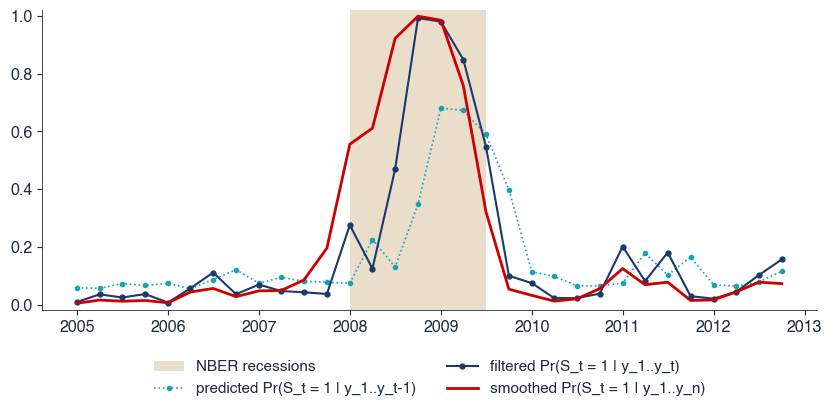

{'f2008q1': 0.2756642686283866, 's2008q1': 0.5555678330555823, 'f2008q3': 0.4692866712396997, 's2008q3': 0.9222922421197776, 'f2008q4': 0.9926263369149232, 's2008q4': 0.9991308143649669, 'f2009q2': 0.8488796613172356, 's2009q2': 0.7586272751613784, 'g2008q3': -0.5266423802783748, 'g2008q4': -2.2133412739485436, 'first_f50': '2008-10-01', 'first_s50': '2008-01-01'}


{'p11': 0.9745305349607013, 'p22': 0.9776257614283388, 'dur1': 39.2627013742545, 'dur2': 44.69425838994053, 'ergodic1': 0.4676527292618652, 'loglik': -348.49634615882917, 'aic': 708.9926923176583, 'bic': 731.0326319206873, 'n': 291, 'const_1': 0.7428635583573997, 'const_2': 0.807900939596862, 'sigma2_1': 0.19358282630114268, 'sigma2_2': 1.431058967593648}
{'p11': 0.00010474284259132272, 'p22': 0.996825618341719, 'dur1': 1.0001047538148036, 'dur2': 315.0219814908854, 'ergodic1': 0.0031646672727817155, 'loglik': -450.18842984126445, 'aic': 910.3768596825289, 'bic': 929.1713685519153, 'n': 317, 'const_1': -8.204350320704457, 'const_2': 0.7900004805627577, 'sigma2': 0.9606155600585243}


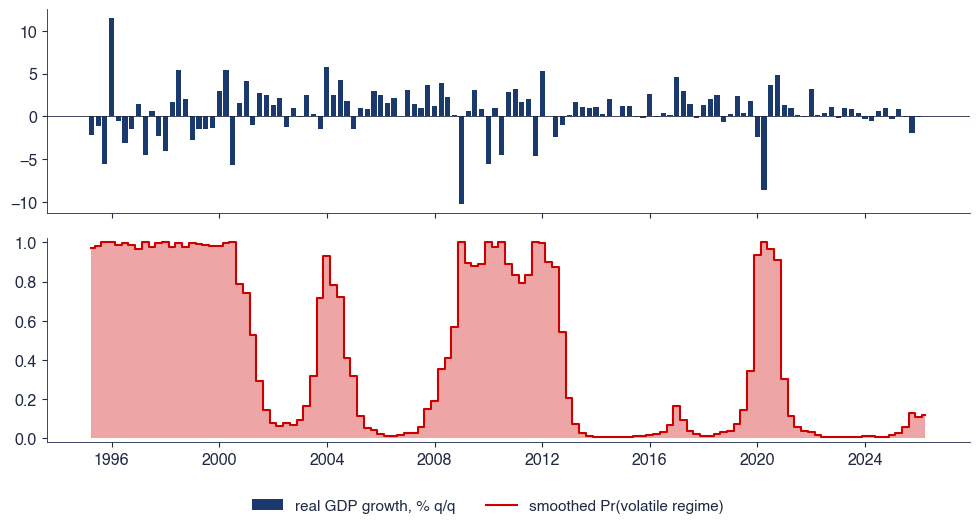

{'p11': 0.9107572227758387, 'p22': 0.9340588633962931, 'dur1': 11.205388616360354, 'dur2': 15.165040390641133, 'ergodic1': 0.4249224998723102, 'loglik': -282.4280208734012, 'aic': 576.8560417468024, 'bic': 593.8259241706162, 'n': 125, 'const_2': 1.0282305444764404, 'const_1': 0.0654948472394623, 'sigma2_2': 1.687898904068718, 'sigma2_1': 15.228856276573152, 'spells': [('1995-04-01', '2001-04-01'), ('2003-10-01', '2004-07-01'), ('2008-10-01', '2012-10-01'), ('2020-01-01', '2020-10-01')], 'share_vol': 0.4, 'first': '1995-04-01', 'last': '2026-04-01', 'sd1': 3.9024167225673314, 'sd2': 1.2991916348517327, 'p_last': 0.11794819395386062}


In [13]:
def fig_ms_us(save_it=True):
    """Hamilton (1989): two-regime Markov-switching mean for US real GDP growth. The original specification
    (MS-AR(4), sample 1951Q2-1984Q4) and a switching mean without AR terms on 1947Q2-2019Q4; smoothed recession
    probabilities against the NBER dates, extended to 2026 with the parameters of 1947-2019."""
    g = us_gdp_growth()
    rec = nber('QS')
    x0 = g.loc[HAMILTON_SAMPLE[0]:HAMILTON_SAMPLE[1]]
    m0 = sm.tsa.MarkovAutoregression(x0.values, k_regimes=2, order=4, switching_ar=False)
    # two local maxima of the likelihood, reached from two starting points:
    # (a) a recession regime of several quarters (Hamilton 1989); (b) a regime of single sharp quarters
    r0 = m0.fit(start_params=[0.75, 0.10, -0.2, 1.3, 0.7, 0.0, 0.0, 0.0, 0.0], disp=False)
    r0b = m0.fit(start_params=[0.15, 0.05, -1.1, 1.0, 0.8, 0.3, 0.15, -0.15, -0.15], disp=False)
    low0, low0b = regime_order(r0)[0], regime_order(r0b)[0]
    x = g.loc[MS_SAMPLE[0]:MS_SAMPLE[1]]
    r = ms_fit(sm.tsa.MarkovRegression(x.values, k_regimes=2))
    low = regime_order(r)[0]
    xa = g.loc[MS_SAMPLE[0]:]
    ma = sm.tsa.MarkovRegression(xa.values, k_regimes=2)
    ra = ma.smooth(r.params)
    sp = pd.Series(ra.smoothed_marginal_probabilities[:, low], index=xa.index)
    fp = pd.Series(ra.filtered_marginal_probabilities[:, low], index=xa.index)
    fig, axes = plt.subplots(2, 1, figsize=(10, 5.4), sharex=True, gridspec_kw={'height_ratios': [1, 1]})
    shade(axes[0], rec.reindex(xa.index))
    axes[0].plot(xa.index, xa.values, color=st.MainBlue, lw=0.9, label='real GDP growth, % q/q')
    axes[0].axhline(0, color=st.DarkText, lw=0.6)
    axes[0].set_ylim(-4, 4)
    shade(axes[1], rec.reindex(xa.index), label='_')
    axes[1].plot(sp.index, sp.values, color=st.IDAred, lw=1.6, label='smoothed Pr(recession regime)')
    axes[1].axvline(pd.Timestamp('2020-01-01'), color=st.Purple, ls='--', lw=1.1, label='end of the estimation sample')
    axes[1].set_ylim(-0.02, 1.02)
    st.fig_legend_bottom(fig, ncol=4, y=0.02)
    fig.tight_layout(rect=(0, 0.06, 1, 1))
    save('tsa_ch10_ms_us', save_it)
    est = sp.loc[:MS_SAMPLE[1]]
    sp0 = pd.Series(r0.smoothed_marginal_probabilities[:, low0], index=x0.index[4:])
    s0, s = ms_summary(r0, x0.index[4:], low0), ms_summary(r, x.index, low)
    post = sp.loc['2020':]
    s0b = ms_summary(r0b, x0.index[4:], low0b)
    sp0b = pd.Series(r0b.smoothed_marginal_probabilities[:, low0b], index=x0.index[4:])
    return {'ham': s0, 'ham_conc': concordance(sp0, rec), 'ham_b': s0b, 'ham_b_conc': concordance(sp0b, rec), 'ext': s, 'ext_conc': concordance(est, rec),
            'ext_conc_f': concordance(fp.loc[:MS_SAMPLE[1]], rec), 'p2020q2': float(sp.loc['2020-04-01']),
            'p2020q3': float(sp.loc['2020-07-01']), 'post_max_after2021': float(post.loc['2021':].max()),
            'n_rec_q': int((rec.reindex(x.index) == 1).sum()), 'first': str(x.index[0].date()), 'last': str(x.index[-1].date()),
            'g2020q2': float(g.loc['2020-04-01']), 'sp_last': float(sp.iloc[-1]), 'last_d': str(sp.index[-1].date())}


def fig_ms_filtered(save_it=True):
    """Filtered (real-time) against smoothed recession probabilities around the 2008-2009 recession."""
    g = us_gdp_growth()
    rec = nber('QS')
    x = g.loc[MS_SAMPLE[0]:MS_SAMPLE[1]]
    r = ms_fit(sm.tsa.MarkovRegression(x.values, k_regimes=2))
    low = regime_order(r)[0]
    sp = pd.Series(r.smoothed_marginal_probabilities[:, low], index=x.index)
    fp = pd.Series(r.filtered_marginal_probabilities[:, low], index=x.index)
    pp = pd.Series(r.predicted_marginal_probabilities[:, low], index=x.index)
    w = slice('2005-01-01', '2012-10-01')
    fig, ax = plt.subplots(figsize=(10, 3.9))
    shade(ax, rec.reindex(x.index).loc[w])
    ax.plot(pp.loc[w].index, pp.loc[w].values, color=st.Teal, lw=1.2, ls=':', marker='.', label='predicted Pr(S_t = 1 | y_1..y_t-1)')
    ax.plot(fp.loc[w].index, fp.loc[w].values, color=st.MainBlue, lw=1.5, marker='o', ms=3.5, label='filtered Pr(S_t = 1 | y_1..y_t)')
    ax.plot(sp.loc[w].index, sp.loc[w].values, color=st.IDAred, lw=2, label='smoothed Pr(S_t = 1 | y_1..y_n)')
    ax.set_ylim(-0.02, 1.02)
    st.legend_outside_bottom(ax, ncol=2, y=-0.12)
    save('tsa_ch10_ms_filtered', save_it)
    q = lambda s, d: float(s.loc[d])
    return {'f2008q1': q(fp, '2008-01-01'), 's2008q1': q(sp, '2008-01-01'), 'f2008q3': q(fp, '2008-07-01'),
            's2008q3': q(sp, '2008-07-01'), 'f2008q4': q(fp, '2008-10-01'), 's2008q4': q(sp, '2008-10-01'),
            'f2009q2': q(fp, '2009-04-01'), 's2009q2': q(sp, '2009-04-01'), 'g2008q3': q(g, '2008-07-01'),
            'g2008q4': q(g, '2008-10-01'), 'first_f50': str(fp.loc['2007':][fp.loc['2007':] > 0.5].index[0].date()),
            'first_s50': str(sp.loc['2007':][sp.loc['2007':] > 0.5].index[0].date())}


def ms_us_pitfalls():
    """Two specifications that find other regimes: a switching variance on 1947-2019 (the Great Moderation) and a
    switching mean on the sample that includes 2020 (a one-quarter pandemic regime)."""
    g = us_gdp_growth()
    rec = nber('QS')
    x = g.loc[MS_SAMPLE[0]:MS_SAMPLE[1]]
    rv = ms_fit(sm.tsa.MarkovRegression(x.values, k_regimes=2, switching_variance=True))
    hv = int(np.argmax([rv.params[rv.model.param_names.index(f'sigma2[{k}]')] for k in range(2)]))
    sp = pd.Series(rv.smoothed_marginal_probabilities[:, hv], index=x.index)
    calm = sp[sp < 0.5]
    xa = g.loc[MS_SAMPLE[0]:]
    ra = ms_fit(sm.tsa.MarkovRegression(xa.values, k_regimes=2))
    lowa = regime_order(ra)[0]
    spa = pd.Series(ra.smoothed_marginal_probabilities[:, lowa], index=xa.index)
    sv = ms_summary(rv, x.index, 1 - hv)
    return {'sv': sv, 'sv_conc': concordance(pd.Series(rv.smoothed_marginal_probabilities[:, hv], index=x.index), rec),
            'sv_switch': str(calm.index[0].date()) if len(calm) else '', 'sv_hv_share_pre84': float((sp.loc[:'1983'] > 0.5).mean()),
            'sv_hv_share_post84': float((sp.loc['1984':] > 0.5).mean()),
            'all': ms_summary(ra, xa.index, lowa), 'all_low_q': [str(d.date()) for d in spa[spa > 0.5].index]}


def fig_ms_ro(save_it=True):
    """Romanian real GDP growth (q/q): two regimes with switching mean and variance (stable and volatile)."""
    y = ro_gdp()
    g = y.diff().dropna()
    r = ms_fit(sm.tsa.MarkovRegression(g.values, k_regimes=2, switching_variance=True))
    hv = int(np.argmax([r.params[r.model.param_names.index(f'sigma2[{k}]')] for k in range(2)]))
    sp = pd.Series(r.smoothed_marginal_probabilities[:, hv], index=g.index)
    fig, axes = plt.subplots(2, 1, figsize=(10, 5.2), sharex=True)
    axes[0].bar(g.index, g.values, width=70, color=st.MainBlue, label='real GDP growth, % q/q')
    axes[0].axhline(0, color=st.DarkText, lw=0.6)
    axes[1].fill_between(sp.index, 0, sp.values, color=st.IDAred, alpha=0.35, lw=0, step='mid', label='_')
    axes[1].plot(sp.index, sp.values, color=st.IDAred, lw=1.5, drawstyle='steps-mid', label='smoothed Pr(volatile regime)')
    axes[1].set_ylim(-0.02, 1.02)
    st.fig_legend_bottom(fig, ncol=2, y=0.05)
    fig.tight_layout(rect=(0, 0.05, 1, 1))
    save('tsa_ch10_ms_ro', save_it)
    s = ms_summary(r, g.index, hv)
    vol = sp > 0.5
    spells, cur = [], None
    for d, v in vol.items():
        if v and cur is None:
            cur = d
        if not v and cur is not None:
            spells.append((str(cur.date()), str(prev.date())))
            cur = None
        prev = d
    if cur is not None:
        spells.append((str(cur.date()), str(prev.date())))
    s.update({'spells': spells, 'share_vol': float(vol.mean()), 'first': str(g.index[0].date()), 'last': str(g.index[-1].date()),
              'sd1': float(np.sqrt(s['sigma2_1'])), 'sd2': float(np.sqrt(s['sigma2_2'])), 'p_last': float(sp.iloc[-1])})
    return s


mu = fig_ms_us(save_it=False)
print(mu['ham'], mu['ham_b'], mu['ext'], mu['ext_conc'], sep='\n')
print(fig_ms_filtered(save_it=False))
pit = ms_us_pitfalls()
print(pit['sv'], pit['all'], sep='\n')
print(fig_ms_ro(save_it=False))

## 8. Volatility regimes, GARCH and long memory

- The simulation takes about a minute; reduce `reps` to go faster.

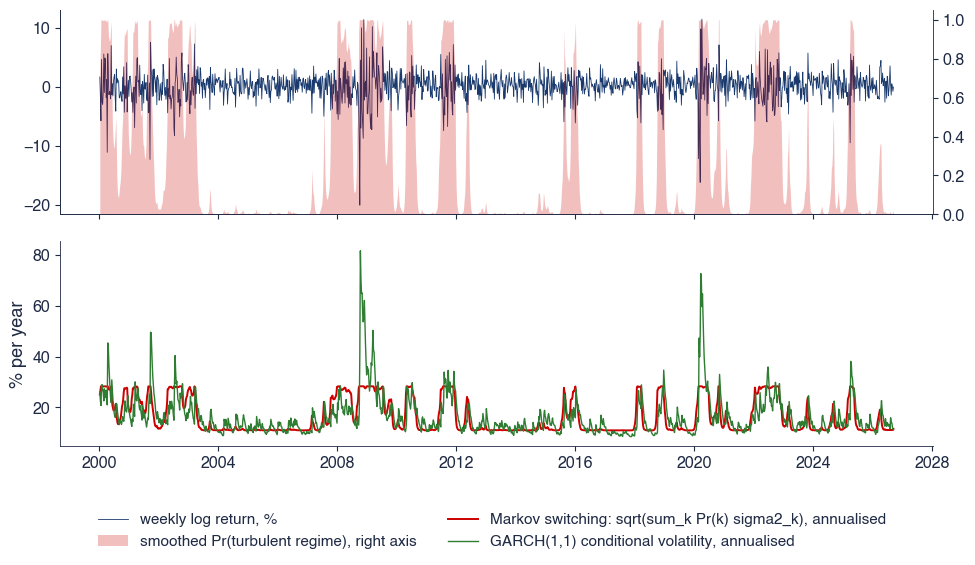

{'p11': 0.9304467491842968, 'p22': 0.9728108676153004, 'dur1': 14.37747320610107, 'dur2': 36.77940089632067, 'ergodic1': 0.2810467499893711, 'loglik': -3019.3268153833396, 'aic': 6050.653630766679, 'bic': 6082.088920609358, 'n': 1393, 'const_2': 0.3196778391777348, 'const_1': -0.39498923633466027, 'sigma2_2': 2.2946585977211758, 'sigma2_1': 15.44228098082071, 'sd1_ann': 28.337230122273365, 'sd2_ann': 10.923472299662828, 'garch_a': 0.2562245499207776, 'garch_b': 0.7030179598501437, 'garch_ab': 0.9592425097709213, 'corr': 0.6844736845915808, 'share_turb': 0.26202440775305097, 'top_years': {'2022': 0.9038461538461539, '2008': 0.7884615384615384, '2009': 0.6923076923076923, '2002': 0.6153846153846154, '2000': 0.6078431372549019}, 'first': '2000-01-14', 'last': '2026-09-18', 'p_last': 0.020085692558899054}


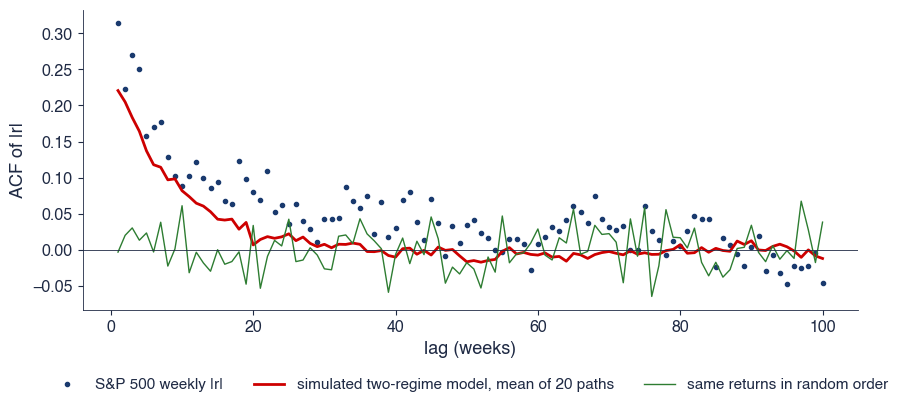

{'acf_data_1': 0.3137628537669879, 'acf_data_26': 0.06297226623065348, 'acf_data_52': 0.023243740390983772, 'acf_sim_1': 0.22062801996712694, 'acf_sim_26': 0.012512692902202385, 'acf_sim_52': -0.01736541713617363, 'd_data': 0.32229426331468003, 'd_sim': 0.29242283095936394, 'd_sim_sd': 0.055708409537646796, 'garch_ab_sim': 0.9093093335072344, 'garch_ab_sim_min': 0.8037353454992313, 'reps': 20, 'reps_garch': 15, 'n': 1393, 'd_iid': 0.04755758256485464}


In [14]:
def fig_vol_regimes(save_it=True):
    """Calm and turbulent regimes of weekly S&P 500 returns (switching mean and variance) and the volatility they
    imply, against the conditional volatility of a GARCH(1,1) (Chapter 5)."""
    from arch import arch_model
    x, r = ms_vol('sp500')
    hv = int(np.argmax([r.params[r.model.param_names.index(f'sigma2[{k}]')] for k in range(2)]))
    sp = pd.Series(r.smoothed_marginal_probabilities[:, hv], index=x.index)
    s2 = np.array([r.params[r.model.param_names.index(f'sigma2[{k}]')] for k in range(2)])
    vol_ms = np.sqrt(r.smoothed_marginal_probabilities @ s2) * np.sqrt(52)
    ga = arch_model(x.values, mean='Constant', vol='GARCH', p=1, q=1, dist='normal').fit(disp='off')
    vol_g = ga.conditional_volatility * np.sqrt(52)
    fig, axes = plt.subplots(2, 1, figsize=(10, 5.4), sharex=True)
    axes[0].plot(x.index, x.values, color=st.MainBlue, lw=0.6, label='weekly log return, %')
    axes0b = axes[0].twinx()
    axes0b.fill_between(sp.index, 0, sp.values, color=st.IDAred, alpha=0.25, lw=0, label='smoothed Pr(turbulent regime), right axis')
    axes0b.set_ylim(0, 1.05)
    axes0b.spines['right'].set_visible(True)
    axes[1].plot(x.index, vol_ms, color=st.IDAred, lw=1.4, label='Markov switching: sqrt(sum_k Pr(k) sigma2_k), annualised')
    axes[1].plot(x.index, vol_g, color=st.Forest, lw=1.0, label='GARCH(1,1) conditional volatility, annualised')
    axes[1].set_ylabel('% per year')
    h1, l1 = axes[0].get_legend_handles_labels()
    h2, l2 = axes0b.get_legend_handles_labels()
    h3, l3 = axes[1].get_legend_handles_labels()
    st.fig_legend_bottom(fig, h1 + h2 + h3, l1 + l2 + l3, ncol=2, y=0.06)
    fig.tight_layout(rect=(0, 0.08, 1, 1))
    save('tsa_ch10_vol_regimes', save_it)
    s = ms_summary(r, x.index, hv)
    pg = ga.params
    turb = sp > 0.5
    ys = turb.groupby(turb.index.year).mean()
    s.update({'sd1_ann': float(np.sqrt(s['sigma2_1'] * 52)), 'sd2_ann': float(np.sqrt(s['sigma2_2'] * 52)),
              'garch_a': float(pg['alpha[1]']), 'garch_b': float(pg['beta[1]']), 'garch_ab': float(pg['alpha[1]'] + pg['beta[1]']),
              'corr': float(np.corrcoef(vol_ms, vol_g)[0, 1]), 'share_turb': float(turb.mean()),
              'top_years': {str(k): float(v) for k, v in ys.sort_values(ascending=False).head(5).items()},
              'first': str(x.index[0].date()), 'last': str(x.index[-1].date()), 'p_last': float(sp.iloc[-1])})
    return s


def fig_regimes_memory(save_it=True, reps=40, L=100):
    """Regimes imitate long memory and GARCH persistence: the ACF of |r| for weekly S&P 500 returns, for series
    simulated from the fitted two-regime model (no GARCH, no long memory) and for i.i.d. returns; local Whittle d of
    |r| and the GARCH(1,1) persistence alpha + beta estimated on the simulated series."""
    from arch import arch_model
    x, r = ms_vol('sp500')
    names = r.model.param_names
    mu = np.array([r.params[names.index(f'const[{k}]')] for k in range(2)])
    s2 = np.array([r.params[names.index(f'sigma2[{k}]')] for k in range(2)])
    P = r.regime_transition[:, :, 0]
    rng = np.random.default_rng(SEED)
    n = len(x)
    acf_data = sm.tsa.acf(np.abs(x.values), nlags=L)[1:]
    sims, ds, abs_ = [], [], []
    for i in range(reps):
        z, _ = simulate_ms(n, mu, s2, P, rng)
        sims.append(sm.tsa.acf(np.abs(z), nlags=L)[1:])
        ds.append(local_whittle(np.abs(z)))
        if i < 15:
            g = arch_model(z, mean='Constant', vol='GARCH', p=1, q=1).fit(disp='off')
            abs_.append(g.params['alpha[1]'] + g.params['beta[1]'])
    acf_sim = np.mean(sims, axis=0)
    iid = rng.permutation(x.values)
    acf_iid = sm.tsa.acf(np.abs(iid), nlags=L)[1:]
    lags = np.arange(1, L + 1)
    fig, ax = plt.subplots(figsize=(10, 3.9))
    ax.plot(lags, acf_data, 'o', ms=3, color=st.MainBlue, label='S&P 500 weekly |r|')
    ax.plot(lags, acf_sim, color=st.IDAred, lw=2, label=f'simulated two-regime model, mean of {reps} paths')
    ax.plot(lags, acf_iid, color=st.Forest, lw=1, label='same returns in random order')
    ax.axhline(0, color=st.DarkText, lw=0.6)
    ax.set_xlabel('lag (weeks)')
    ax.set_ylabel('ACF of |r|')
    st.legend_outside_bottom(ax, ncol=3, y=-0.18)
    save('tsa_ch10_regimes_memory', save_it)
    return {'acf_data_1': float(acf_data[0]), 'acf_data_26': float(acf_data[25]), 'acf_data_52': float(acf_data[51]),
            'acf_sim_1': float(acf_sim[0]), 'acf_sim_26': float(acf_sim[25]), 'acf_sim_52': float(acf_sim[51]),
            'd_data': local_whittle(np.abs(x.values)), 'd_sim': float(np.mean(ds)), 'd_sim_sd': float(np.std(ds)),
            'garch_ab_sim': float(np.mean(abs_)), 'garch_ab_sim_min': float(np.min(abs_)), 'reps': reps, 'reps_garch': len(abs_),
            'n': int(n), 'd_iid': local_whittle(np.abs(iid))}


print(fig_vol_regimes(save_it=False))
print(fig_regimes_memory(save_it=False, reps=20))

## Exercises

1. Fit a local linear trend (`UnobservedComponents(y, 'lltrend')`) to the Nile and compare its BIC with the local level.
2. Estimate the Romanian output gap with a damped stochastic cycle (`cycle=True, stochastic_cycle=True, damped_cycle=True`) and compare it with the AR(2) cycle.
3. Fit a three-regime volatility model to weekly S&P 500 returns and compare its BIC with two regimes.